# Multi-task нейросеть intent + topic для DialogSum-RU

Этот блокнот реализует **многозадачную (multi-task) нейросетевую модель**, которая
одновременно решает две задачи на репликах диалогов DialogSum-RU:

1. **Основная задача — intent detection.** Определение намерения говорящего по реплике
   (`intent_label`).
2. **Вспомогательная задача — topic cluster prediction.** Предсказание идентификатора
   тематического кластера `cluster_id`, полученного эмбеддинговой кластеризацией в
   блокноте `08_topic_modeling_dialogsum_ru.ipynb`.

Идея в том, что вспомогательная задача предсказания тематического кластера выступает
**индуктивным смещением (inductive bias)** для энкодера: модель вынуждена выучивать
представления, чувствительные не только к коммуникативному намерению, но и к смысловой
теме реплики. Это особенно полезно в условиях **слабой разметки intent-меток** (weak
labels), полученных эвристиками в блокнотах `09`/`10`.

### Принципиальная разница: topic как задача vs как признак

Важно понимать, что в проекте используются два **разных** способа задействовать
тематическую информацию:

- В блокноте `09_intent_modeling_dialogsum_ru.ipynb` `cluster_id` подаётся как
  **внешний признак** (one-hot/embedding) на вход классическому или линейному
  классификатору intent. Тематика влияет на предсказание только через явный сигнал.
- В этом блокноте `cluster_id` — это **отдельная цель обучения (auxiliary task)**.
  Модель не видит идентификатор кластера на входе, а должна его предсказать сама.
  Это заставляет общий энкодер выучивать тема-чувствительные представления и не
  даёт градиентам intent-головы «забыть» о теме.

Эти два способа не взаимоисключающие — здесь мы оцениваем именно вторую гипотезу:
помогает ли совместное обучение представления при слабой разметке intent.

### План блокнота

1. Импорты и конфигурация.
2. Монтирование Google Drive и пути проекта.
3. Загрузка, очистка и **диагностика** данных (распределения классов, пересечения сплитов).
4. Dataset и DataLoader'ы под HuggingFace токенизатор.
5. Архитектура multi-task модели и single-task baseline.
6. Утилиты обучения, валидации, **early stopping** и **class weights**.
7. Обучение single-task baseline (только intent).
8. Обучение multi-task модели (intent + topic) и опциональный **ablation по `lambda_topic`**.
9. Сравнение метрик single-task vs multi-task на test.
10. Анализ ошибок, **confusion matrix отдельно для каждой модели**, top confusions,
    error examples.
11. Сохранение артефактов в Google Drive.
12. Интерпретация фактических результатов и выводы.

### Замечания

- Используются **PyTorch + HuggingFace Transformers** (без Keras/TensorFlow).
- Платные внешние API не задействованы.
- Код проверяет наличие GPU (`torch.cuda`) и корректно откатывается на CPU.
- В реальной работе при отсутствии GPU стоит уменьшить `EPOCHS` и/или задать
  `MAX_SAMPLES` для отладки.


## Ячейка 1 — Импорты и глобальные настройки

Конфигурация управляется флагами:

- `MODEL_NAME` — энкодер. По умолчанию используется русский диалоговый
  `DeepPavlov/rubert-base-cased-conversational` (на двух прогонах он стабильно
  показывал лучший intent macro-F1 среди доступных вариантов).
- `USE_UNCERTAINTY_WEIGHTING` — homoscedastic-uncertainty веса задач
  (Kendall et al., 2018). В текущем прогоне ухудшил intent macro-F1
  (`0.5415` против `0.6804` single-task), поэтому **по умолчанию выключен**
  и оставлен только как experimental ablation.
- `USE_COARSE_TOPIC_HEAD` — третья голова для грубой тематической категории
  (`coarse_topic_label`) как auxiliary task.
- `LAMBDA_TOPIC` — вес fine-grained topic auxiliary loss. Эксперименты
  показали, что `0.1` даёт лучший intent (`f1_macro=0.6888` vs `0.6804`
  single-task), `0.5` уже снижает intent F1, а `1.0` сильно вредит.
  Topic-сигнал полезен **только как слабая регуляризация**.
- `CLASS_WEIGHT_MODE` — балансировка intent CE-loss. `sqrt` (по умолчанию)
  применяет `balanced` веса в степени `CLASS_WEIGHT_POWER` (=0.5) и затем
  нормирует на `mean=1`, что мягче чистого `balanced` для перекоса.
- `DETACH_TOPIC_GRAD` — если `True`, fine-grained topic head обучается без
  пробрасывания градиента в энкодер. Это нужно, чтобы topic не разрушал
  intent-представления, оставаясь диагностической auxiliary-задачей.
- `ACTIVE_LEARNING_*` — параметры пула, дедупликации и diversity-ограничений
  для отбора кандидатов на ручную разметку (см. финальную ячейку).

Смена `MODEL_NAME` требует пересоздания токенизатора, датасета и повторного
обучения, поэтому изменения вступают в силу только при полном перезапуске
блокнота начиная с ячейки 1.


In [1]:
# cell 1: imports and config
# Если пакеты не установлены в Colab/Perplexity Compute, раскомментируйте строку ниже:
!pip install -q transformers accelerate scikit-learn pandas numpy matplotlib seaborn tqdm joblib pyarrow

import os
import re
import json
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from tqdm.auto import tqdm
import joblib

warnings.filterwarnings('ignore')

# ----------------------------- Конфигурация -----------------------------
RANDOM_STATE = 42

# Базовая модель-энкодер. Рекомендуемый русский диалоговый энкодер —
# DeepPavlov/rubert-base-cased-conversational (180M параметров, 768-dim,
# дообучен на OpenSubtitles + социальных текстах).
# Альтернативы:
#   'DeepPavlov/rubert-base-cased'                                  — общий русский BERT (Wiki+News)
#   'xlm-roberta-base'                                              — кросс-языковой baseline
#   'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'   — компактный многоязычный sentence encoder
# ВНИМАНИЕ: смена MODEL_NAME требует пересоздания tokenizer/dataset
# (ячейка 4) и повторного обучения моделей с нуля (ячейки 7, 8).
MODEL_NAME = 'DeepPavlov/rubert-base-cased-conversational'

MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 10
LR = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.1
GRAD_CLIP = 1.0

# Многозадачный лосс. На текущих данных uncertainty-weighting ухудшил
# intent macro-F1 (0.5415 против 0.6804 у single-task), поэтому **выключен
# по умолчанию** и оставлен только как experimental ablation. Рабочая
# рекомендуемая конфигурация — ручные lambda с маленьким весом topic-головы.
USE_UNCERTAINTY_WEIGHTING = False  # experimental, currently worse
LAMBDA_INTENT = 1.0
LAMBDA_TOPIC = 0.1            # 0.1 даёт лучший intent F1; 0.5 уже снижает; 1.0 вредит
LAMBDA_COARSE_TOPIC = 0.1

# Дополнительная грубая (агрегированная) topic-голова — auxiliary task
# с меньшим числом классов, использует иерархическую структуру тем.
USE_COARSE_TOPIC_HEAD = True

# Подготовка данных
TOP_N_CLUSTERS = 10        # Кол-во наиболее частых не-шумовых кластеров для topic head
MIN_INTENT_COUNT = 20      # Минимальная встречаемость intent-класса (иначе фильтруем)
MAX_SAMPLES = None         # Ограничение размера выборки для отладки (None = без ограничений)

# Доп. опции
FREEZE_ENCODER = False     # Если True, обучается только head; полезно на CPU
USE_CLASS_WEIGHTS = True   # Балансировка лоссов через class weights (полезно при дисбалансе)
# Режим сглаживания intent class weights:
#   'none'     — все веса 1.0;
#   'balanced' — sklearn compute_class_weight('balanced');
#   'sqrt'     — balanced ** CLASS_WEIGHT_POWER, затем нормировка на mean=1
#                (мягче для сильного перекоса; используется по умолчанию).
CLASS_WEIGHT_MODE = 'sqrt'
CLASS_WEIGHT_POWER = 0.5

# Detach gradient у вспомогательных голов: если True, topic_head обучается без
# обратного распространения в энкодер (он остаётся диагностической задачей,
# а не движущей силой представлений). По умолчанию detach для fine-grained
# topic включён, для coarse-topic — выключен (грубая категория содержит
# полезный иерархический сигнал).
DETACH_TOPIC_GRAD = True
DETACH_COARSE_TOPIC_GRAD = False

PATIENCE = 2               # Early stopping: число эпох без улучшения val_intent_f1_macro
RUN_ABLATION = False       # Запуск multi-task ablation с другим LAMBDA_TOPIC (см. ячейку 8b)
ABLATION_LAMBDAS = [0.1, 1.0]  # Значения LAMBDA_TOPIC для ablation, если RUN_ABLATION=True

# Active learning (финальная ячейка): отбор top-N наиболее неопределённых
# примеров с дедупликацией и diversity-ограничениями.
ACTIVE_LEARNING_CANDIDATE_POOL = 500
ACTIVE_LEARNING_TOP_N = 100
ACTIVE_LEARNING_MAX_PER_PRED_INTENT = 15
ACTIVE_LEARNING_MAX_PER_CLUSTER = 15

# ----------------------------- Воспроизводимость -----------------------------
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch версия: {torch.__version__}')
print(f'CUDA доступна: {torch.cuda.is_available()}')
print(f'Используемое устройство: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('Предупреждение: тренировка на CPU будет медленной. Рассмотрите уменьшение EPOCHS или установку MAX_SAMPLES.')


PyTorch версия: 2.11.0+cu128
CUDA доступна: True
Используемое устройство: cuda
GPU: NVIDIA A100-SXM4-80GB


## Ячейка 2 — Google Drive и пути проекта

Монтируем Google Drive (в Colab) и фиксируем пути к таблицам, фигурам и моделям проекта.


In [2]:
# cell 2: Google Drive and project paths
try:
    from google.colab import drive  # type: ignore

    if not os.path.exists("/content/drive/MyDrive"):
        drive.mount("/content/drive")
    else:
        print("Google Drive уже смонтирован.")
except ModuleNotFoundError:
    print("google.colab не найден: пропускаем монтирование Google Drive.")

BASE_DIR = Path("/content/drive/MyDrive/russian-dialogue-intent-thesis")
TABLES_DIR = BASE_DIR / "results" / "tables"
FIGURES_DIR = BASE_DIR / "results" / "figures"
MODELS_DIR = BASE_DIR / "models" / "multitask_intent_topic"

if not BASE_DIR.exists():
    print(f"Предупреждение: базовая директория проекта {BASE_DIR} не существует.")
    print(
        "Если вы работаете локально или без Google Drive, обновите пути выше вручную."
    )
else:
    print(f"BASE_DIR найдена: {BASE_DIR}")

# Создаём только подкаталоги для результатов и моделей (не весь BASE_DIR молча)
for d in [FIGURES_DIR, MODELS_DIR]:
    try:
        d.mkdir(parents=True, exist_ok=True)
    except OSError as e:
        print(f"Не удалось создать {d}: {e}")

print(f"TABLES_DIR:  {TABLES_DIR}")
print(f"FIGURES_DIR: {FIGURES_DIR}")
print(f"MODELS_DIR:  {MODELS_DIR}")

Mounted at /content/drive
BASE_DIR найдена: /content/drive/MyDrive/russian-dialogue-intent-thesis
TABLES_DIR:  /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables
FIGURES_DIR: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures
MODELS_DIR:  /content/drive/MyDrive/russian-dialogue-intent-thesis/models/multitask_intent_topic


## Ячейка 3 — Загрузка и подготовка данных

Логика загрузки:

1. **Предпочтительный путь:** weak utterance dataset из блокнотов `09`/`10`
   (`dialogsum_ru_intent_utterances_weak.parquet`/`.csv`).
2. **Fallback:** восстановление из topic clusters файла блокнота `08`
   (`dialogsum_ru_topic_clusters_sota.parquet`/`.csv`) с разбиением `dialogue` на
   реплики `#Person1#`/`#Person2#` и присвоением rule-based intent-меток.
3. Если нет ни того, ни другого — выдаём осмысленную ошибку с подсказкой запустить `08`/`09`/`10`.


In [3]:
# cell 3: load and prepare data
WEAK_PARQUET = TABLES_DIR / "dialogsum_ru_intent_utterances_weak.parquet"
WEAK_CSV = TABLES_DIR / "dialogsum_ru_intent_utterances_weak.csv"
TOPIC_PARQUET = TABLES_DIR / "dialogsum_ru_topic_clusters_sota.parquet"
TOPIC_CSV = TABLES_DIR / "dialogsum_ru_topic_clusters_sota.csv"

USED_FALLBACK = False


def _read_any(parquet_path: Path, csv_path: Path):
    if parquet_path.exists():
        print(f"Читаю parquet: {parquet_path}")
        return pd.read_parquet(parquet_path)
    if csv_path.exists():
        print(f"Читаю csv: {csv_path}")
        return pd.read_csv(csv_path)
    return None


# ----------------------------- Rule-based intent (fallback) -----------------------------
_INTENT_RULES = [
    (
        "greeting",
        re.compile(
            r"\b(привет|здравствуй|здравствуйте|добрый\s+(день|вечер|утро)|hello|hi)\b",
            re.I,
        ),
    ),
    (
        "farewell",
        re.compile(r"\b(пока|до\s+свидан|удач|всего\s+доброго|bye|goodbye)\b", re.I),
    ),
    ("thanks", re.compile(r"\b(спасибо|благодар|thanks|thank you)\b", re.I)),
    (
        "confirmation",
        re.compile(
            r"^(\s*)(да|конечно|разумеется|хорошо|ладно|ок|окей|yes|sure|ok|okay)\b",
            re.I,
        ),
    ),
    ("rejection", re.compile(r"^(\s*)(нет|не\s+могу|не\s+хочу|no|nope)\b", re.I)),
    (
        "clarification_request",
        re.compile(
            r"(что\s+вы\s+имеете|что\s+значит|повторите|уточните|можете\s+пояснить|what\s+do\s+you\s+mean)",
            re.I,
        ),
    ),
    (
        "service_request",
        re.compile(
            r"(закажу|оформ|забронируй|подключите|сделайте|выпиш|please\s+(do|set|book))",
            re.I,
        ),
    ),
    (
        "purchase_or_booking_request",
        re.compile(
            r"(купить|приобрест|заказ|бронир|оплат|купи|book|purchase|order)", re.I
        ),
    ),
    (
        "complaint",
        re.compile(
            r"(жалоб|недоволен|возмут|ужасн|отвратитель|complaint|terrible|awful)", re.I
        ),
    ),
    (
        "problem_report",
        re.compile(
            r"(не\s+работает|сломал|ошибк|проблем|broken|not\s+working|error)", re.I
        ),
    ),
    (
        "arrangement",
        re.compile(
            r"(встрет|договор|назнач|перенес|встреча|let\'s\s+meet|schedule)", re.I
        ),
    ),
    (
        "suggestion_or_recommendation",
        re.compile(
            r"(рекоменду|советую|предлага|стоит\s+попробовать|recommend|suggest)", re.I
        ),
    ),
    (
        "opinion_or_preference",
        re.compile(
            r"(нравится|предпочит|думаю,?\s+что|по\s+моему\s+мнению|i\s+think|prefer|like)",
            re.I,
        ),
    ),
    (
        "informational_request",
        re.compile(
            r"^[^?]*\?\s*$|\b(кто|что|когда|где|как|почему|сколько|what|how|when|where|why)\b.*\?",
            re.I,
        ),
    ),
]

INTENT_CLASSES = [
    "greeting",
    "thanks",
    "farewell",
    "informational_request",
    "clarification_request",
    "service_request",
    "purchase_or_booking_request",
    "complaint",
    "problem_report",
    "arrangement",
    "confirmation",
    "rejection",
    "suggestion_or_recommendation",
    "opinion_or_preference",
    "other",
]


def rule_based_intent(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return "other"
    for label, pattern in _INTENT_RULES:
        if pattern.search(text):
            return label
    return "other"


_SPEAKER_RE = re.compile(r"#Person([12])#\s*[:：]?\s*", re.IGNORECASE)


def split_dialogue_to_utterances(dialogue: str):
    if not isinstance(dialogue, str):
        return []
    parts = _SPEAKER_RE.split(dialogue)
    utterances = []
    i = 1
    while i + 1 < len(parts):
        speaker = f"Person{parts[i]}"
        text = parts[i + 1].strip()
        if text:
            utterances.append((speaker, text))
        i += 2
    return utterances


def build_fallback_from_topics(topics_df: pd.DataFrame) -> pd.DataFrame:
    print("Восстанавливаю weak utterance dataset из topic clusters (fallback).")
    dialogue_col = (
        "dialogue"
        if "dialogue" in topics_df.columns
        else ("dialogue_ru" if "dialogue_ru" in topics_df.columns else None)
    )
    if dialogue_col is None:
        raise ValueError(
            "В topic clusters не найдена колонка dialogue/dialogue_ru — невозможно построить fallback."
        )
    if "cluster_id" not in topics_df.columns:
        raise ValueError(
            "В topic clusters отсутствует cluster_id — fallback невозможен."
        )

    id_col = "dialogue_id" if "dialogue_id" in topics_df.columns else None
    name_col = "cluster_name" if "cluster_name" in topics_df.columns else None

    rows = []
    for _, r in topics_df.iterrows():
        utts = split_dialogue_to_utterances(r[dialogue_col])
        for idx, (sp, txt) in enumerate(utts):
            rows.append(
                {
                    "dialogue_id": r[id_col] if id_col else None,
                    "utterance_idx": idx,
                    "speaker": sp,
                    "utterance_text": txt,
                    "cluster_id": r["cluster_id"],
                    "cluster_name": r[name_col] if name_col else None,
                }
            )
    df = pd.DataFrame(rows)
    df["intent_label"] = df["utterance_text"].apply(rule_based_intent)
    df["is_fallback_weak"] = True
    return df


# ----------------------------- Иерархия тем (coarse / агрегированная) -----------------------------
# Грубые макрокатегории, агрегирующие fine-grained cluster_id/cluster_name
# в небольшое число семантически связных групп.
#
# Основной способ: явный mapping по top-10 cluster_id, полученным из блокнота 08.
# Это надёжнее, чем regex по cluster_name, и даёт интерпретируемые coarse-метки.
# Fallback: keyword-эвристика по cluster_name, если cluster_id не в mapping;
# в крайнем случае — 'прочее'.

COARSE_TOPIC_MAP = {
    28: "работа_образование",  # Собеседование
    169: "работа_образование",  # Работа
    114: "работа_образование",  # Образование
    77: "культура_досуг",  # музыкальные события
    202: "культура_досуг",  # развлечения
    186: "культура_досуг",  # Поиск книг
    145: "дом_сервис",  # Дом и его состояние
    187: "дом_сервис",  # ремонт и обслуживание
    206: "путешествия_сервис",  # Выезд и путешествия
    204: "жалобы_проблемы",  # Пожаловаться на человека
}

_COARSE_TOPIC_KEYWORDS = [
    (
        "работа_образование",
        [
            "работ",
            "собеседован",
            "образован",
            "учёб",
            "учеб",
            "школ",
            "универс",
            "колледж",
            "карьер",
            "офис",
            "employ",
            "job",
            "school",
            "study",
            "work",
        ],
    ),
    (
        "путешествия_сервис",
        [
            "путешеств",
            "поездк",
            "отель",
            "бронир",
            "travel",
            "hotel",
            "book",
        ],
    ),
    (
        "дом_сервис",
        [
            "ремонт",
            "обслуж",
            "дом",
            "кварт",
            "service",
            "repair",
        ],
    ),
    (
        "культура_досуг",
        [
            "развлеч",
            "музык",
            "кино",
            "фильм",
            "книг",
            "концерт",
            "досуг",
            "отдых",
            "entertain",
            "music",
            "movie",
            "leisure",
        ],
    ),
    (
        "жалобы_проблемы",
        [
            "жалоб",
            "жалов",
            "проблем",
            "недоволь",
            "возмут",
            "неисправн",
            "сломал",
            "complaint",
            "problem",
            "broken",
            "error",
        ],
    ),
]


def infer_coarse_topic(cluster_name, cluster_id):
    """Определяет coarse-категорию по cluster_id (точный mapping) или cluster_name (keyword fallback).

    Приоритет:
    1. COARSE_TOPIC_MAP[cluster_id] — явный mapping по top-10 cluster_id.
    2. Keyword-поиск по cluster_name.
    3. 'прочее' как fallback.
    """
    try:
        cid = int(cluster_id)
        if cid in COARSE_TOPIC_MAP:
            return COARSE_TOPIC_MAP[cid]
    except (TypeError, ValueError):
        cid = None

    if isinstance(cluster_name, str) and cluster_name.strip():
        name_lc = cluster_name.lower()
        for coarse, keywords in _COARSE_TOPIC_KEYWORDS:
            for kw in keywords:
                if kw in name_lc:
                    return coarse
    return "прочее"


# ----------------------------- Основная загрузка -----------------------------
df = _read_any(WEAK_PARQUET, WEAK_CSV)
if df is None:
    topics_df = _read_any(TOPIC_PARQUET, TOPIC_CSV)
    if topics_df is None:
        raise FileNotFoundError(
            "Не найдены ни weak utterance dataset, ни topic clusters. "
            "Сначала запустите блокноты 08_topic_modeling_dialogsum_ru.ipynb, "
            "09_intent_modeling_dialogsum_ru.ipynb или 10_intent_manual_validation_dialogsum_ru.ipynb."
        )
    df = build_fallback_from_topics(topics_df)
    USED_FALLBACK = True
else:
    df["is_fallback_weak"] = False

required_cols = ["utterance_text", "intent_label", "cluster_id"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"В исходных данных отсутствуют обязательные колонки: {missing}")

print(f"Загружено строк: {len(df)} | fallback weak: {USED_FALLBACK}")
print("Колонки:", list(df.columns))

# ----------------------------- Очистка -----------------------------
df = df.dropna(subset=["utterance_text", "intent_label", "cluster_id"]).copy()
df["utterance_text"] = df["utterance_text"].astype(str).str.strip()
df = df[df["utterance_text"].str.len() > 0]
df["cluster_id"] = df["cluster_id"].astype(int)

# ----------------------------- Дедупликация ----------------------------------
# Датасет — utterance-level: одинаковые реплики (особенно короткие: «Да»,
# «Спасибо», «Хорошо») встречаются многократно с разными dialogue_id. Если их
# не убрать ДО split, идентичные тексты попадут одновременно в train и test —
# это утечка (data leakage) и грубо завышает метрики. Ключ дедупликации —
# нормализованный текст реплики (lower + strip + схлопывание whitespace), а не
# id, т.к. дубликаты имеют разные id. Дедуп выполняется на общем df ДО
# фильтраций, кодирования меток и split, поэтому затрагивает все задачи сразу.
_n_before_dedup = len(df)
df["dedup_key"] = (
    df["utterance_text"].str.lower().str.replace(r"\s+", " ", regex=True).str.strip()
)
_dup_counts = df["dedup_key"].value_counts()
_n_dup_keys = int((_dup_counts > 1).sum())
df = df.drop_duplicates(subset="dedup_key", keep="first").reset_index(drop=True)
_n_after_dedup = len(df)
_n_removed = _n_before_dedup - _n_after_dedup
print(
    f"Дедупликация по нормализованному тексту реплики: "
    f"было {_n_before_dedup}, удалено дублей {_n_removed}, "
    f"стало {_n_after_dedup} ({_n_dup_keys} ключей имели >1 вхождения)."
)
if _n_dup_keys:
    print("Топ-10 дублировавшихся реплик (key[:60], count):")
    for _key, _cnt in _dup_counts.head(10).items():
        print(f"  {_cnt:>5}x  {repr(_key[:60])}")
# dedup_key больше не нужен в пайплайне — убираем, чтобы не мешать downstream.
df = df.drop(columns="dedup_key")

# Если cluster_name отсутствует — пометим явный технический fallback ниже.
if "cluster_name" not in df.columns:
    df["cluster_name"] = None
HAS_CLUSTER_NAME = df["cluster_name"].notna().any()
if not HAS_CLUSTER_NAME:
    print(
        "cluster_name отсутствует в данных — coarse_topic_label будет построен "
        "через технический fallback cluster_id % 4."
    )

# Для topic head убираем шумовой кластер (-1) и оставляем top-N не-шумовых
non_noise = df[df["cluster_id"] != -1]
top_clusters = (
    non_noise["cluster_id"].value_counts().head(TOP_N_CLUSTERS).index.tolist()
)
print(f"Топ-{TOP_N_CLUSTERS} не-шумовых кластеров (cluster_id): {top_clusters}")
df = df[df["cluster_id"].isin(top_clusters)].copy()

# Фильтрация редких intent-классов
intent_counts = df["intent_label"].value_counts()
rare = intent_counts[intent_counts < MIN_INTENT_COUNT].index.tolist()
if rare:
    print(f"Отфильтровываю редкие intent-классы (<{MIN_INTENT_COUNT}): {rare}")
    df = df[~df["intent_label"].isin(rare)].copy()

if MAX_SAMPLES is not None and len(df) > MAX_SAMPLES:
    df = df.sample(n=MAX_SAMPLES, random_state=RANDOM_STATE).reset_index(drop=True)
    print(f"Применён MAX_SAMPLES={MAX_SAMPLES}, итоговый размер: {len(df)}")

# ----------------------------- Coarse topic label ----------------------------
df["coarse_topic_label"] = df.apply(
    lambda r: infer_coarse_topic(r.get("cluster_name"), r.get("cluster_id")),
    axis=1,
)
print("Распределение coarse_topic_label:")
print(df["coarse_topic_label"].value_counts())

# ----------------------------- Кодирование меток -----------------------------
intent_encoder = LabelEncoder()
df["intent_id"] = intent_encoder.fit_transform(df["intent_label"])

topic_encoder = LabelEncoder()
df["topic_id"] = topic_encoder.fit_transform(df["cluster_id"])

coarse_topic_encoder = LabelEncoder()
df["coarse_topic_id"] = coarse_topic_encoder.fit_transform(df["coarse_topic_label"])

NUM_INTENTS = len(intent_encoder.classes_)
NUM_TOPICS = len(topic_encoder.classes_)
NUM_COARSE_TOPICS = len(coarse_topic_encoder.classes_)
print(f"Кол-во intent-классов: {NUM_INTENTS} -> {list(intent_encoder.classes_)}")
print(f"Кол-во topic-классов: {NUM_TOPICS} -> {list(topic_encoder.classes_)}")
print(
    f"Кол-во coarse-topic классов: {NUM_COARSE_TOPICS} -> {list(coarse_topic_encoder.classes_)}"
)

# ----------------------------- Train/val/test split --------------------------
try:
    train_df, temp_df = train_test_split(
        df,
        test_size=0.30,
        stratify=df["intent_id"],
        random_state=RANDOM_STATE,
    )
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df["intent_id"],
        random_state=RANDOM_STATE,
    )
except ValueError as e:
    print(f"Стратификация не удалась ({e}), повторяю без стратификации.")
    train_df, temp_df = train_test_split(df, test_size=0.30, random_state=RANDOM_STATE)
    val_df, test_df = train_test_split(
        temp_df, test_size=0.50, random_state=RANDOM_STATE
    )

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Размеры: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
print("Распределение intent на train:")
print(train_df["intent_label"].value_counts())

Читаю parquet: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/dialogsum_ru_intent_utterances_weak.parquet
Загружено строк: 4722 | fallback weak: False
Колонки: ['utterance_id', 'dialogue_id', 'split', 'cluster_id', 'cluster_name', 'speaker', 'turn_idx', 'utterance_text', 'topic', 'summary', 'intent_label', 'intent_rule_reason', 'is_fallback_weak']
Дедупликация по нормализованному тексту реплики: было 4722, удалено дублей 425, стало 4297 (330 ключей имели >1 вхождения).
Топ-10 дублировавшихся реплик (key[:60], count):
     10x  'почему?'
      8x  'могу я вам помочь?'
      6x  'понятно.'
      6x  'до свидания.'
      6x  'спасибо.'
      5x  'большое спасибо.'
      5x  'верно.'
      5x  'что ты читаешь?'
      5x  'что-то не так с моим компьютером.'
      5x  'могу я вам помочь, сэр?'
Топ-10 не-шумовых кластеров (cluster_id): [28, 114, 145, 77, 204, 202, 187, 206, 186, 169]
Распределение coarse_topic_label:
coarse_topic_label
работа_образование    1336
культура

## Ячейка 3b — Диагностика данных

Перед обучением убеждаемся, что распределения intent и topic вменяемы, а классы
действительно представлены во всех сплитах. Если какой-то редкий intent отсутствует в
val/test, это сразу видно — иначе мы рискуем получить «странные» макро-метрики на
несуществующих классах.

Результаты диагностики сохраняем в `class_balance_df` и пишем CSV
`dialogsum_ru_multitask_class_balance.csv` в `TABLES_DIR`.


In [4]:
# cell 3b: data diagnostics — class balance and split coverage


def _counts(series: pd.Series, classes):
    c = series.value_counts().to_dict()
    return [int(c.get(cls, 0)) for cls in classes]


# ---- Intent class balance per split ----
intent_classes_sorted = list(intent_encoder.classes_)
intent_balance = pd.DataFrame(
    {
        "intent_label": intent_classes_sorted,
        "train_count": _counts(train_df["intent_label"], intent_classes_sorted),
        "val_count": _counts(val_df["intent_label"], intent_classes_sorted),
        "test_count": _counts(test_df["intent_label"], intent_classes_sorted),
    }
)
intent_balance["total"] = intent_balance[
    ["train_count", "val_count", "test_count"]
].sum(axis=1)
intent_balance["train_share"] = intent_balance["train_count"] / max(len(train_df), 1)
print("Распределение intent по сплитам:")
print(intent_balance.to_string(index=False))

# ---- Topic (cluster_id) balance per split ----
topic_classes_sorted = [int(x) for x in topic_encoder.classes_]
topic_balance = pd.DataFrame(
    {
        "cluster_id": topic_classes_sorted,
        "train_count": _counts(train_df["cluster_id"], topic_classes_sorted),
        "val_count": _counts(val_df["cluster_id"], topic_classes_sorted),
        "test_count": _counts(test_df["cluster_id"], topic_classes_sorted),
    }
)
topic_balance["total"] = topic_balance[["train_count", "val_count", "test_count"]].sum(
    axis=1
)
print("\nРаспределение topic-кластеров по сплитам:")
print(topic_balance.to_string(index=False))

# ---- Coverage warnings ----
print("\nПроверка покрытия классов в val/test:")
missing_in_val_intent = intent_balance[intent_balance["val_count"] == 0][
    "intent_label"
].tolist()
missing_in_test_intent = intent_balance[intent_balance["test_count"] == 0][
    "intent_label"
].tolist()
rare_in_val_intent = intent_balance[
    (intent_balance["val_count"] > 0) & (intent_balance["val_count"] < 3)
]["intent_label"].tolist()

if missing_in_val_intent:
    print(f"  ВНИМАНИЕ: intent-классы отсутствуют в val: {missing_in_val_intent}")
if missing_in_test_intent:
    print(f"  ВНИМАНИЕ: intent-классы отсутствуют в test: {missing_in_test_intent}")
if rare_in_val_intent:
    print(
        f"  ВНИМАНИЕ: очень редкие intent-классы в val (<3 примеров): {rare_in_val_intent}"
    )
if not (missing_in_val_intent or missing_in_test_intent or rare_in_val_intent):
    print("  Все intent-классы представлены в val/test разумным числом примеров.")

missing_in_val_topic = topic_balance[topic_balance["val_count"] == 0][
    "cluster_id"
].tolist()
missing_in_test_topic = topic_balance[topic_balance["test_count"] == 0][
    "cluster_id"
].tolist()
if missing_in_val_topic:
    print(f"  ВНИМАНИЕ: topic-кластеры отсутствуют в val: {missing_in_val_topic}")
if missing_in_test_topic:
    print(f"  ВНИМАНИЕ: topic-кластеры отсутствуют в test: {missing_in_test_topic}")

# ---- Save class_balance_df ----
intent_balance_out = intent_balance.copy()
intent_balance_out.insert(0, "level", "intent")
intent_balance_out = intent_balance_out.rename(columns={"intent_label": "class"})

topic_balance_out = topic_balance.copy()
topic_balance_out.insert(0, "level", "topic")
topic_balance_out = topic_balance_out.rename(columns={"cluster_id": "class"})
topic_balance_out["class"] = topic_balance_out["class"].astype(str)

class_balance_df = pd.concat([intent_balance_out, topic_balance_out], ignore_index=True)
class_balance_csv = TABLES_DIR / "dialogsum_ru_multitask_class_balance.csv"
try:
    class_balance_csv.parent.mkdir(parents=True, exist_ok=True)
    class_balance_df.to_csv(class_balance_csv, index=False)
    print(
        f"\nclass_balance_df сохранён: {class_balance_csv} ({len(class_balance_df)} строк)"
    )
except OSError as e:
    print(f"Не удалось сохранить {class_balance_csv}: {e}")

Распределение intent по сплитам:
                intent_label  train_count  val_count  test_count  total  train_share
                 arrangement           41          9           9     59     0.013635
                   complaint           23          5           5     33     0.007649
                confirmation          225         48          48    321     0.074825
                    farewell           41          9           9     59     0.013635
                    greeting          127         27          27    181     0.042235
       informational_request         1322        284         283   1889     0.439641
       opinion_or_preference           52         11          11     74     0.017293
                       other          800        172         172   1144     0.266046
              problem_report           41          9           8     58     0.013635
 purchase_or_booking_request           58         12          13     83     0.019288
                   rejection    

## Ячейка 4 — Dataset и DataLoader

Оборачиваем данные в `torch.utils.data.Dataset` и подключаем HuggingFace токенизатор.


In [5]:
# cell 4: dataset and dataloaders
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Токенизатор {MODEL_NAME} загружен. Vocab size: {tokenizer.vocab_size}")


class DialogSumIntentTopicDataset(Dataset):
    def __init__(self, dataframe: pd.DataFrame, tokenizer, max_len: int = MAX_LEN):
        self.texts = dataframe["utterance_text"].tolist()
        self.intents = dataframe["intent_id"].tolist()
        self.topics = dataframe["topic_id"].tolist()
        self.coarse_topics = dataframe["coarse_topic_id"].tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "intent_label": torch.tensor(self.intents[idx], dtype=torch.long),
            "topic_label": torch.tensor(self.topics[idx], dtype=torch.long),
            "coarse_topic_label": torch.tensor(
                self.coarse_topics[idx], dtype=torch.long
            ),
        }


train_ds = DialogSumIntentTopicDataset(train_df, tokenizer)
val_ds = DialogSumIntentTopicDataset(val_df, tokenizer)
test_ds = DialogSumIntentTopicDataset(test_df, tokenizer)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(
    f"Батчей: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}"
)

config.json:   0%|          | 0.00/642 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/24.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/1.40M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Токенизатор DeepPavlov/rubert-base-cased-conversational загружен. Vocab size: 100792
Батчей: train=188, val=41, test=41


## Ячейка 4b — Class weights для борьбы с дисбалансом

Распределение intent-меток сильно перекошено: классы `informational_request` и `other`
доминируют, а `complaint`, `arrangement`, `suggestion_or_recommendation` встречаются
редко. Это означает, что обычный `CrossEntropyLoss` будет «занят» в основном частыми
классами, а редкие будут «затоптаны» — отсюда нулевые F1 по редким классам в первом
прогоне.

`CLASS_WEIGHT_MODE` управляет сглаживанием весов intent-головы:

- `none` — все веса 1.0 (никакой коррекции);
- `balanced` — стандартные `sklearn` balanced веса;
- `sqrt` (по умолчанию) — `balanced ** CLASS_WEIGHT_POWER`, затем нормировка на `mean=1`.
  Такое сглаживание мягче «крутых» balanced весов и помогает не «выламывать» модель
  в сторону редких классов при умеренном перекосе.

Для topic и coarse-topic голов оставлены стандартные balanced веса —
эти задачи диагностические и не требуют тонкой настройки.


In [6]:
# cell 4b: class weights (intent + topic + coarse topic)
def _compute_smoothed_intent_weights(y_train_ids, num_classes, mode="sqrt", power=0.5):
    """Возвращает (np.ndarray весов длины num_classes, описание режима).

    Режимы:
      - 'none'     -> все веса 1.0;
      - 'balanced' -> sklearn compute_class_weight('balanced');
      - 'sqrt'     -> balanced ** power, затем нормировка mean=1
                      (мягче для сильного перекоса).
    """
    class_ids = np.arange(num_classes)
    if mode == "none":
        w = np.ones(num_classes, dtype=float)
        return w, "none (все веса = 1.0)"
    balanced = compute_class_weight(
        class_weight="balanced",
        classes=class_ids,
        y=y_train_ids,
    )
    if mode == "balanced":
        return balanced, "balanced (без сглаживания)"
    if mode == "sqrt":
        w = np.power(balanced, power)
        w = w * (len(w) / w.sum())  # нормировка на mean=1
        return w, f"sqrt (balanced ** {power}, нормировка mean=1)"
    raise ValueError(f"Неизвестный CLASS_WEIGHT_MODE: {mode}")


if USE_CLASS_WEIGHTS:
    intent_weights_np, intent_weight_descr = _compute_smoothed_intent_weights(
        train_df["intent_id"].values,
        NUM_INTENTS,
        mode=CLASS_WEIGHT_MODE,
        power=CLASS_WEIGHT_POWER,
    )
    intent_class_weights = torch.tensor(intent_weights_np, dtype=torch.float).to(DEVICE)

    # Для topic / coarse topic оставляем стандартный 'balanced' — там перекос
    # обычно слабее, и эти задачи в любом случае диагностические.
    topic_class_ids = np.arange(NUM_TOPICS)
    topic_weights_np = compute_class_weight(
        class_weight="balanced",
        classes=topic_class_ids,
        y=train_df["topic_id"].values,
    )
    topic_class_weights = torch.tensor(topic_weights_np, dtype=torch.float).to(DEVICE)

    coarse_class_ids = np.arange(NUM_COARSE_TOPICS)
    coarse_weights_np = compute_class_weight(
        class_weight="balanced",
        classes=coarse_class_ids,
        y=train_df["coarse_topic_id"].values,
    )
    coarse_topic_class_weights = torch.tensor(coarse_weights_np, dtype=torch.float).to(
        DEVICE
    )

    print(f"CLASS_WEIGHT_MODE={CLASS_WEIGHT_MODE!r}, описание: {intent_weight_descr}")
    intent_weights_table = pd.DataFrame(
        {
            "intent_label": intent_encoder.classes_,
            "weight": intent_weights_np,
        }
    ).sort_values("weight", ascending=False)
    print("Class weights (intent, после сглаживания):")
    print(intent_weights_table.to_string(index=False))
    print("\nClass weights (topic, cluster_id -> weight):")
    print(
        pd.DataFrame(
            {
                "cluster_id": topic_encoder.classes_,
                "weight": topic_weights_np,
            }
        ).to_string(index=False)
    )
    print("\nClass weights (coarse topic):")
    print(
        pd.DataFrame(
            {
                "coarse_topic_label": coarse_topic_encoder.classes_,
                "weight": coarse_weights_np,
            }
        ).to_string(index=False)
    )
else:
    intent_class_weights = None
    topic_class_weights = None
    coarse_topic_class_weights = None
    intent_weight_descr = "disabled"
    print("Class weights отключены (USE_CLASS_WEIGHTS=False).")

CLASS_WEIGHT_MODE='sqrt', описание: sqrt (balanced ** 0.5, нормировка mean=1)
Class weights (intent, после сглаживания):
                intent_label   weight
suggestion_or_recommendation 1.751778
                   complaint 1.713273
                    farewell 1.283212
                 arrangement 1.283212
              problem_report 1.283212
       opinion_or_preference 1.139433
 purchase_or_booking_request 1.078888
             service_request 0.891212
                      thanks 0.891212
                   rejection 0.891212
                    greeting 0.729102
                confirmation 0.547771
                       other 0.290500
       informational_request 0.225982

Class weights (topic, cluster_id -> weight):
 cluster_id   weight
         28 0.861605
         77 0.945597
        114 0.894940
        145 1.029795
        169 1.134717
        186 1.097445
        187 0.992409
        202 0.992409
        204 1.026280
        206 1.097445

Class weights (coarse topic):
c

## Ячейка 5 — Архитектура моделей

- **MultiTaskIntentTopicModel** — общий энкодер (HuggingFace `AutoModel`), mean pooling
  по attention mask, общая проекция и три головы: `intent_head`, `topic_head`,
  `coarse_topic_head`. Поддерживает `detach_topic_grad` / `detach_coarse_topic_grad`:
  если True, соответствующая голова получает `shared_repr.detach()` и обучается
  как диагностическая auxiliary-задача без пробрасывания градиента в энкодер.
  Это важно потому, что fine-grained topic (10 кластеров) на практике конфликтует
  с intent — он «перетягивает» энкодер и роняет intent F1. Detach позволяет
  сохранить диагностический topic-сигнал без разрушения intent-представлений.
- **SingleTaskIntentModel** — тот же энкодер + проекция + только `intent_head`.
  Служит baseline для сравнения.

Совместный лосс: `L = lambda_intent * CE(intent) + lambda_topic * CE(topic)` (+ coarse),
причём все `CrossEntropyLoss` могут принимать `weight=...` (class weights).


In [7]:
# cell 5: multitask model definition
from transformers import AutoModel


def mean_pool(
    last_hidden_state: torch.Tensor, attention_mask: torch.Tensor
) -> torch.Tensor:
    mask = attention_mask.unsqueeze(-1).float()
    summed = (last_hidden_state * mask).sum(dim=1)
    counts = mask.sum(dim=1).clamp(min=1e-9)
    return summed / counts


def _uncertainty_weighted_loss(
    raw_loss: torch.Tensor, log_var: torch.Tensor
) -> torch.Tensor:
    """Uncertainty-weighted loss для одной задачи классификации.

    L_uw = 0.5 * exp(-s) * L + 0.5 * s, где s = log sigma^2 — обучаемый параметр.
    Для численной стабильности log_var клампится в диапазон [-5, 5].
    """
    s = torch.clamp(log_var, min=-5.0, max=5.0)
    precision = 0.5 * torch.exp(-s)
    return precision * raw_loss + 0.5 * s


class MultiTaskIntentTopicModel(nn.Module):
    """Multi-task модель с тремя головами: intent + fine topic + coarse topic.

    Поддерживает:
    - `use_coarse_topic_head` — включает третью голову для грубой категории;
    - `use_uncertainty_weighting` — homoscedastic-uncertainty веса задач
      (Kendall et al., 2018), экспериментальный режим;
    - `detach_topic_grad` / `detach_coarse_topic_grad` — если True, соответствующая
      голова получает `shared_repr.detach()`, т.е. обучается как диагностическая
      auxiliary-задача без пробрасывания градиента в энкодер. Это полезно, когда
      topic-задача конфликтует с intent (fine-grained topic регулярно ухудшает
      intent F1, если ему позволить переписывать энкодер).
    """

    def __init__(
        self,
        base_model_name: str,
        num_intents: int,
        num_topics: int,
        num_coarse_topics: int = 0,
        dropout: float = 0.1,
        freeze_encoder: bool = False,
        intent_weight: torch.Tensor = None,
        topic_weight: torch.Tensor = None,
        coarse_topic_weight: torch.Tensor = None,
        use_uncertainty_weighting: bool = False,
        use_coarse_topic_head: bool = True,
        detach_topic_grad: bool = True,
        detach_coarse_topic_grad: bool = False,
    ):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base_model_name)
        hidden = self.encoder.config.hidden_size

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

        self.shared_proj = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )
        self.intent_head = nn.Linear(hidden, num_intents)
        self.topic_head = nn.Linear(hidden, num_topics)

        self.use_coarse_topic_head = bool(
            use_coarse_topic_head and num_coarse_topics > 0
        )
        if self.use_coarse_topic_head:
            self.coarse_topic_head = nn.Linear(hidden, num_coarse_topics)
        else:
            self.coarse_topic_head = None

        self.detach_topic_grad = bool(detach_topic_grad)
        self.detach_coarse_topic_grad = bool(detach_coarse_topic_grad)

        self.loss_fn_intent = nn.CrossEntropyLoss(weight=intent_weight)
        self.loss_fn_topic = nn.CrossEntropyLoss(weight=topic_weight)
        self.loss_fn_coarse = (
            nn.CrossEntropyLoss(weight=coarse_topic_weight)
            if self.use_coarse_topic_head
            else None
        )

        self.use_uncertainty_weighting = bool(use_uncertainty_weighting)
        # Обучаемые log_var параметры (s = log sigma^2). Инициализация в 0 -> sigma=1.
        self.log_var_intent = nn.Parameter(torch.zeros(1))
        self.log_var_topic = nn.Parameter(torch.zeros(1))
        if self.use_coarse_topic_head:
            # Coarse-task проще -> чуть ниже стартовая дисперсия.
            self.log_var_coarse_topic = nn.Parameter(torch.tensor([-0.5]))
        else:
            self.register_parameter("log_var_coarse_topic", None)

    def effective_weights(self) -> dict:
        """Текущие эффективные веса задач (для логирования)."""
        w = {
            "intent_weight_eff": float(
                0.5
                * torch.exp(
                    -torch.clamp(self.log_var_intent.detach(), min=-5.0, max=5.0)
                ).item()
            ),
            "topic_weight_eff": float(
                0.5
                * torch.exp(
                    -torch.clamp(self.log_var_topic.detach(), min=-5.0, max=5.0)
                ).item()
            ),
        }
        if self.use_coarse_topic_head:
            w["coarse_topic_weight_eff"] = float(
                0.5
                * torch.exp(
                    -torch.clamp(self.log_var_coarse_topic.detach(), min=-5.0, max=5.0)
                ).item()
            )
        return w

    def forward(
        self,
        input_ids,
        attention_mask,
        intent_labels=None,
        topic_labels=None,
        coarse_topic_labels=None,
        lambda_intent: float = LAMBDA_INTENT,
        lambda_topic: float = LAMBDA_TOPIC,
        lambda_coarse_topic: float = LAMBDA_COARSE_TOPIC,
    ):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = mean_pool(out.last_hidden_state, attention_mask)
        shared_repr = self.shared_proj(pooled)

        intent_logits = self.intent_head(shared_repr)

        if self.detach_topic_grad:
            topic_repr = shared_repr.detach()
        else:
            topic_repr = shared_repr
        topic_logits = self.topic_head(topic_repr)

        result = {"intent_logits": intent_logits, "topic_logits": topic_logits}

        if self.use_coarse_topic_head:
            if self.detach_coarse_topic_grad:
                coarse_repr = shared_repr.detach()
            else:
                coarse_repr = shared_repr
            coarse_logits = self.coarse_topic_head(coarse_repr)
            result["coarse_topic_logits"] = coarse_logits

        if intent_labels is not None and topic_labels is not None:
            l_intent = self.loss_fn_intent(intent_logits, intent_labels)
            l_topic = self.loss_fn_topic(topic_logits, topic_labels)
            result["loss_intent"] = l_intent
            result["loss_topic"] = l_topic

            l_coarse = None
            if self.use_coarse_topic_head and coarse_topic_labels is not None:
                l_coarse = self.loss_fn_coarse(
                    result["coarse_topic_logits"], coarse_topic_labels
                )
                result["loss_coarse_topic"] = l_coarse

            if self.use_uncertainty_weighting:
                loss = _uncertainty_weighted_loss(
                    l_intent, self.log_var_intent
                ) + _uncertainty_weighted_loss(l_topic, self.log_var_topic)
                if l_coarse is not None:
                    loss = loss + _uncertainty_weighted_loss(
                        l_coarse, self.log_var_coarse_topic
                    )
            else:
                loss = lambda_intent * l_intent + lambda_topic * l_topic
                if l_coarse is not None:
                    loss = loss + lambda_coarse_topic * l_coarse

            result["loss"] = loss
        return result


class SingleTaskIntentModel(nn.Module):
    def __init__(
        self,
        base_model_name: str,
        num_intents: int,
        dropout: float = 0.1,
        freeze_encoder: bool = False,
        intent_weight: torch.Tensor = None,
    ):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(base_model_name)
        hidden = self.encoder.config.hidden_size

        if freeze_encoder:
            for p in self.encoder.parameters():
                p.requires_grad = False

        self.proj = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.GELU(),
            nn.LayerNorm(hidden),
            nn.Dropout(dropout),
        )
        self.intent_head = nn.Linear(hidden, num_intents)
        self.loss_fn_intent = nn.CrossEntropyLoss(weight=intent_weight)

    def forward(self, input_ids, attention_mask, intent_labels=None, **kwargs):
        out = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        pooled = mean_pool(out.last_hidden_state, attention_mask)
        proj = self.proj(pooled)
        intent_logits = self.intent_head(proj)
        result = {"intent_logits": intent_logits}
        if intent_labels is not None:
            result["loss"] = self.loss_fn_intent(intent_logits, intent_labels)
            result["loss_intent"] = result["loss"]
        return result

## Ячейка 6 — Утилиты обучения с early stopping

Функции `train_one_epoch` / `evaluate` и обёртка `fit_model`. Лучшая эпоха выбирается
по `val_intent_f1_macro`; если метрика не улучшается `PATIENCE` эпох подряд — обучение
останавливается. Полная история обучения логируется и возвращается как `history` (DataFrame).


In [8]:
# cell 6: training utilities with early stopping
from transformers import get_linear_schedule_with_warmup
import copy


def train_one_epoch(
    model,
    loader,
    optimizer,
    scheduler,
    device,
    multitask: bool,
    lambda_intent: float = LAMBDA_INTENT,
    lambda_topic: float = LAMBDA_TOPIC,
    lambda_coarse_topic: float = LAMBDA_COARSE_TOPIC,
):
    model.train()
    total_loss = 0.0
    total_intent_loss = 0.0
    total_topic_loss = 0.0
    total_coarse_loss = 0.0
    n_batches = 0
    pbar = tqdm(loader, desc="train", leave=False)
    for batch in pbar:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        intent_labels = batch["intent_label"].to(device)

        if multitask:
            topic_labels = batch["topic_label"].to(device)
            coarse_topic_labels = batch.get("coarse_topic_label")
            if coarse_topic_labels is not None:
                coarse_topic_labels = coarse_topic_labels.to(device)
            out = model(
                input_ids,
                attention_mask,
                intent_labels=intent_labels,
                topic_labels=topic_labels,
                coarse_topic_labels=coarse_topic_labels,
                lambda_intent=lambda_intent,
                lambda_topic=lambda_topic,
                lambda_coarse_topic=lambda_coarse_topic,
            )
        else:
            out = model(input_ids, attention_mask, intent_labels=intent_labels)

        loss = out["loss"]
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        if scheduler is not None:
            scheduler.step()

        total_loss += loss.item()
        total_intent_loss += out.get("loss_intent", loss).item()
        if "loss_topic" in out:
            total_topic_loss += out["loss_topic"].item()
        if "loss_coarse_topic" in out:
            total_coarse_loss += out["loss_coarse_topic"].item()
        n_batches += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    stats = {
        "train_loss": total_loss / max(n_batches, 1),
        "train_intent_loss": total_intent_loss / max(n_batches, 1),
    }
    if multitask:
        stats["train_topic_loss"] = total_topic_loss / max(n_batches, 1)
        stats["train_coarse_topic_loss"] = (
            total_coarse_loss / max(n_batches, 1)
            if getattr(model, "use_coarse_topic_head", False)
            else None
        )
    return stats


@torch.no_grad()
def evaluate(model, loader, device, multitask: bool):
    model.eval()
    all_intent_preds, all_intent_labels = [], []
    all_topic_preds, all_topic_labels = [], []
    all_coarse_preds, all_coarse_labels = [], []
    total_loss = 0.0
    n_batches = 0
    has_coarse_head = getattr(model, "use_coarse_topic_head", False)
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        intent_labels = batch["intent_label"].to(device)

        if multitask:
            topic_labels = batch["topic_label"].to(device)
            coarse_topic_labels = batch.get("coarse_topic_label")
            if coarse_topic_labels is not None:
                coarse_topic_labels = coarse_topic_labels.to(device)
            out = model(
                input_ids,
                attention_mask,
                intent_labels=intent_labels,
                topic_labels=topic_labels,
                coarse_topic_labels=coarse_topic_labels,
            )
        else:
            out = model(input_ids, attention_mask, intent_labels=intent_labels)

        if "loss" in out:
            total_loss += out["loss"].item()
        n_batches += 1

        intent_preds = out["intent_logits"].argmax(dim=-1).cpu().numpy()
        all_intent_preds.extend(intent_preds.tolist())
        all_intent_labels.extend(intent_labels.cpu().numpy().tolist())

        if multitask and "topic_logits" in out:
            topic_preds = out["topic_logits"].argmax(dim=-1).cpu().numpy()
            all_topic_preds.extend(topic_preds.tolist())
            all_topic_labels.extend(topic_labels.cpu().numpy().tolist())

        if (
            multitask
            and has_coarse_head
            and "coarse_topic_logits" in out
            and coarse_topic_labels is not None
        ):
            coarse_preds = out["coarse_topic_logits"].argmax(dim=-1).cpu().numpy()
            all_coarse_preds.extend(coarse_preds.tolist())
            all_coarse_labels.extend(coarse_topic_labels.cpu().numpy().tolist())

    metrics = {
        "val_loss": total_loss / max(n_batches, 1),
        "intent_accuracy": accuracy_score(all_intent_labels, all_intent_preds),
        "intent_f1_macro": f1_score(
            all_intent_labels, all_intent_preds, average="macro", zero_division=0
        ),
        "intent_f1_micro": f1_score(
            all_intent_labels, all_intent_preds, average="micro", zero_division=0
        ),
        "intent_f1_weighted": f1_score(
            all_intent_labels, all_intent_preds, average="weighted", zero_division=0
        ),
    }
    if multitask and all_topic_labels:
        metrics["topic_accuracy"] = accuracy_score(all_topic_labels, all_topic_preds)
        metrics["topic_f1_macro"] = f1_score(
            all_topic_labels, all_topic_preds, average="macro", zero_division=0
        )
    if multitask and all_coarse_labels:
        metrics["coarse_topic_accuracy"] = accuracy_score(
            all_coarse_labels, all_coarse_preds
        )
        metrics["coarse_topic_f1_macro"] = f1_score(
            all_coarse_labels, all_coarse_preds, average="macro", zero_division=0
        )
    metrics["_intent_preds"] = all_intent_preds
    metrics["_intent_labels"] = all_intent_labels
    metrics["_topic_preds"] = all_topic_preds
    metrics["_topic_labels"] = all_topic_labels
    metrics["_coarse_topic_preds"] = all_coarse_preds
    metrics["_coarse_topic_labels"] = all_coarse_labels
    return metrics


def fit_model(
    model,
    train_loader,
    val_loader,
    device,
    multitask: bool,
    epochs: int = EPOCHS,
    lr: float = LR,
    patience: int = PATIENCE,
    lambda_intent: float = LAMBDA_INTENT,
    lambda_topic: float = LAMBDA_TOPIC,
    lambda_coarse_topic: float = LAMBDA_COARSE_TOPIC,
    tag: str = "model",
):
    optimizer = AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=WEIGHT_DECAY,
    )
    total_steps = len(train_loader) * epochs
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

    history = []
    best_f1 = -1.0
    best_state = None
    epochs_without_improve = 0

    for epoch in range(1, epochs + 1):
        train_stats = train_one_epoch(
            model,
            train_loader,
            optimizer,
            scheduler,
            device,
            multitask,
            lambda_intent=lambda_intent,
            lambda_topic=lambda_topic,
            lambda_coarse_topic=lambda_coarse_topic,
        )
        val_stats = evaluate(model, val_loader, device, multitask)
        log = {
            **train_stats,
            **{k: v for k, v in val_stats.items() if not k.startswith("_")},
            "epoch": epoch,
            "tag": tag,
        }
        # Логируем эффективные веса задач при uncertainty weighting
        if multitask and hasattr(model, "effective_weights"):
            log.update(model.effective_weights())
            log["log_var_intent"] = float(model.log_var_intent.detach().item())
            log["log_var_topic"] = float(model.log_var_topic.detach().item())
            if getattr(model, "use_coarse_topic_head", False):
                log["log_var_coarse_topic"] = float(
                    model.log_var_coarse_topic.detach().item()
                )
        history.append(log)
        msg = (
            f"[{tag}] Epoch {epoch}/{epochs} | train_loss={log['train_loss']:.4f} | "
            f"val_loss={log['val_loss']:.4f} | intent_acc={log['intent_accuracy']:.4f} | "
            f"intent_f1_macro={log['intent_f1_macro']:.4f}"
        )
        if multitask:
            msg += f" | topic_acc={log.get('topic_accuracy', 0):.4f}"
            if "coarse_topic_accuracy" in log:
                msg += f" | coarse_topic_acc={log['coarse_topic_accuracy']:.4f}"
            if "intent_weight_eff" in log:
                msg += (
                    f" | w_int={log['intent_weight_eff']:.3f}"
                    f" w_top={log['topic_weight_eff']:.3f}"
                )
                if "coarse_topic_weight_eff" in log:
                    msg += f" w_coarse={log['coarse_topic_weight_eff']:.3f}"
        print(msg)
        if val_stats["intent_f1_macro"] > best_f1:
            best_f1 = val_stats["intent_f1_macro"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improve = 0
            print(f"  -> новый лучший val_intent_f1_macro={best_f1:.4f}")
        else:
            epochs_without_improve += 1
            print(f"  -> улучшения нет ({epochs_without_improve}/{patience})")
            if epochs_without_improve >= patience:
                print(f"  Early stopping: метрика не растёт {patience} эпох подряд.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    history_df = pd.DataFrame(history)
    return model, history_df, best_state

## Ячейка 7 — Обучение single-task baseline

Тренируем baseline-модель, которая решает только intent detection. Это нижняя планка
для сравнения. Используем class weights (если включены) для борьбы с дисбалансом.


In [9]:
# cell 7: train single-task baseline
print("=== Обучение SingleTaskIntentModel (baseline) ===")
single_model = SingleTaskIntentModel(
    base_model_name=MODEL_NAME,
    num_intents=NUM_INTENTS,
    freeze_encoder=FREEZE_ENCODER,
    intent_weight=intent_class_weights,
).to(DEVICE)
n_params = sum(p.numel() for p in single_model.parameters() if p.requires_grad)
print(f"Обучаемых параметров: {n_params:,}")

single_model, single_history_df, single_best_state = fit_model(
    single_model,
    train_loader,
    val_loader,
    DEVICE,
    multitask=False,
    tag="single_task",
)

print("\n--- Финальная валидация single-task ---")
single_val_metrics = evaluate(single_model, val_loader, DEVICE, multitask=False)
for k, v in single_val_metrics.items():
    if not k.startswith("_") and isinstance(v, float):
        print(f"  {k}: {v:.4f}")

=== Обучение SingleTaskIntentModel (baseline) ===


pytorch_model.bin:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased-conversational
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Обучаемых параметров: 178,456,334


...

[single_task] Epoch 6/10 | train_loss=0.0014 | val_loss=0.6117 | intent_acc=0.9163 | intent_f1_macro=0.7979
  -> новый лучший val_intent_f1_macro=0.7979


train:   0%|          | 0/188 [00:00<?, ?it/s]

[single_task] Epoch 7/10 | train_loss=0.0007 | val_loss=0.6734 | intent_acc=0.9070 | intent_f1_macro=0.7836
  -> улучшения нет (1/2)


train:   0%|          | 0/188 [00:00<?, ?it/s]

[single_task] Epoch 8/10 | train_loss=0.0005 | val_loss=0.7224 | intent_acc=0.9163 | intent_f1_macro=0.7947
  -> улучшения нет (2/2)
  Early stopping: метрика не растёт 2 эпох подряд.

--- Финальная валидация single-task ---
  val_loss: 0.6117
  intent_accuracy: 0.9163
  intent_f1_macro: 0.7979
  intent_f1_micro: 0.9163
  intent_f1_weighted: 0.9149


## Ячейка 8 — Обучение multi-task модели

Тренируем `MultiTaskIntentTopicModel` с двумя головами и совместным лоссом
`L = LAMBDA_INTENT * CE(intent) + LAMBDA_TOPIC * CE(topic)`. Class weights применяются
к обеим CE-функциям независимо (если включены).


In [10]:
# cell 8: train multi-task model
print("=== Обучение MultiTaskIntentTopicModel ===")
print(
    f"USE_UNCERTAINTY_WEIGHTING={USE_UNCERTAINTY_WEIGHTING}, "
    f"USE_COARSE_TOPIC_HEAD={USE_COARSE_TOPIC_HEAD}, "
    f"NUM_COARSE_TOPICS={NUM_COARSE_TOPICS}"
)
multi_model = MultiTaskIntentTopicModel(
    base_model_name=MODEL_NAME,
    num_intents=NUM_INTENTS,
    num_topics=NUM_TOPICS,
    num_coarse_topics=NUM_COARSE_TOPICS,
    freeze_encoder=FREEZE_ENCODER,
    intent_weight=intent_class_weights,
    topic_weight=topic_class_weights,
    coarse_topic_weight=coarse_topic_class_weights,
    use_uncertainty_weighting=USE_UNCERTAINTY_WEIGHTING,
    use_coarse_topic_head=USE_COARSE_TOPIC_HEAD,
    detach_topic_grad=DETACH_TOPIC_GRAD,
    detach_coarse_topic_grad=DETACH_COARSE_TOPIC_GRAD,
).to(DEVICE)
n_params = sum(p.numel() for p in multi_model.parameters() if p.requires_grad)
print(f"Обучаемых параметров: {n_params:,}")

tag_suffix = "uw" if USE_UNCERTAINTY_WEIGHTING else f"lam{LAMBDA_TOPIC}"
if USE_COARSE_TOPIC_HEAD:
    tag_suffix += "_coarse"

multi_model, multi_history_df, multi_best_state = fit_model(
    multi_model,
    train_loader,
    val_loader,
    DEVICE,
    multitask=True,
    lambda_intent=LAMBDA_INTENT,
    lambda_topic=LAMBDA_TOPIC,
    lambda_coarse_topic=LAMBDA_COARSE_TOPIC,
    tag=f"multi_task_{tag_suffix}",
)

print("\n--- Финальная валидация multi-task ---")
multi_val_metrics = evaluate(multi_model, val_loader, DEVICE, multitask=True)
for k, v in multi_val_metrics.items():
    if not k.startswith("_") and isinstance(v, float):
        print(f"  {k}: {v:.4f}")

if USE_UNCERTAINTY_WEIGHTING:
    print("\nИтоговые эффективные веса задач (uncertainty weighting):")
    for k, v in multi_model.effective_weights().items():
        print(f"  {k}: {v:.4f}")

=== Обучение MultiTaskIntentTopicModel ===
USE_UNCERTAINTY_WEIGHTING=False, USE_COARSE_TOPIC_HEAD=True, NUM_COARSE_TOPICS=5


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: DeepPavlov/rubert-base-cased-conversational
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Обучаемых параметров: 178,467,872


train:   0%|          | 0/188 [00:00<?, ?it/s]

...

[multi_task_lam0.1_coarse] Epoch 4/10 | train_loss=0.4075 | val_loss=0.9327 | intent_acc=0.8961 | intent_f1_macro=0.7606 | topic_acc=0.1550 | coarse_topic_acc=0.4713 | w_int=0.500 w_top=0.500 w_coarse=0.824
  -> новый лучший val_intent_f1_macro=0.7606


train:   0%|          | 0/188 [00:00<?, ?it/s]

[multi_task_lam0.1_coarse] Epoch 5/10 | train_loss=0.3319 | val_loss=0.9545 | intent_acc=0.8853 | intent_f1_macro=0.7035 | topic_acc=0.2000 | coarse_topic_acc=0.4620 | w_int=0.500 w_top=0.500 w_coarse=0.824
  -> улучшения нет (1/2)


train:   0%|          | 0/188 [00:00<?, ?it/s]

[multi_task_lam0.1_coarse] Epoch 6/10 | train_loss=0.2779 | val_loss=1.0048 | intent_acc=0.8915 | intent_f1_macro=0.7302 | topic_acc=0.2140 | coarse_topic_acc=0.4837 | w_int=0.500 w_top=0.500 w_coarse=0.824
  -> улучшения нет (2/2)
  Early stopping: метрика не растёт 2 эпох подряд.

--- Финальная валидация multi-task ---
  val_loss: 0.9327
  intent_accuracy: 0.8961
  intent_f1_macro: 0.7606
  intent_f1_micro: 0.8961
  intent_f1_weighted: 0.8941
  topic_accuracy: 0.1550
  topic_f1_macro: 0.1495
  coarse_topic_accuracy: 0.4713
  coarse_topic_f1_macro: 0.4162


## Ячейка 8b — Опциональный ablation по `lambda_topic`

Чтобы проверить, насколько чувствительна модель к весу вспомогательной задачи,
можно запустить дополнительные multi-task прогоны с другими значениями
`LAMBDA_TOPIC`. По умолчанию `RUN_ABLATION = False`, потому что каждый прогон
дорогой по GPU. Чтобы запустить ablation, поставьте `RUN_ABLATION = True` в
**Ячейке 1** и при необходимости измените `ABLATION_LAMBDAS`.

Функция `run_multitask_experiment(lambda_topic)` инкапсулирует один прогон и
возвращает обученную модель, историю и тестовые метрики.


In [11]:
# cell 8b: optional lambda_topic ablation


def run_multitask_experiment(
    lambda_topic: float,
    lambda_intent: float = LAMBDA_INTENT,
    tag_prefix: str = "multi_task",
):
    """Полный прогон multi-task модели с заданным lambda_topic.

    Запускается только при USE_UNCERTAINTY_WEIGHTING=False (иначе lambda не используется).
    Возвращает словарь: model, history_df, val_metrics, test_metrics.
    """
    tag = f"{tag_prefix}_lam{lambda_topic}"
    print(f"\n=== ABLATION: lambda_topic={lambda_topic} ===")
    model = MultiTaskIntentTopicModel(
        base_model_name=MODEL_NAME,
        num_intents=NUM_INTENTS,
        num_topics=NUM_TOPICS,
        num_coarse_topics=NUM_COARSE_TOPICS,
        freeze_encoder=FREEZE_ENCODER,
        intent_weight=intent_class_weights,
        topic_weight=topic_class_weights,
        coarse_topic_weight=coarse_topic_class_weights,
        use_uncertainty_weighting=False,
        use_coarse_topic_head=USE_COARSE_TOPIC_HEAD,
        detach_topic_grad=DETACH_TOPIC_GRAD,
        detach_coarse_topic_grad=DETACH_COARSE_TOPIC_GRAD,
    ).to(DEVICE)
    model, history_df, _ = fit_model(
        model,
        train_loader,
        val_loader,
        DEVICE,
        multitask=True,
        lambda_intent=lambda_intent,
        lambda_topic=lambda_topic,
        lambda_coarse_topic=LAMBDA_COARSE_TOPIC,
        tag=tag,
    )
    val_metrics = evaluate(model, val_loader, DEVICE, multitask=True)
    test_metrics = evaluate(model, test_loader, DEVICE, multitask=True)
    return {
        "tag": tag,
        "lambda_topic": lambda_topic,
        "model": model,
        "history_df": history_df,
        "val_metrics": val_metrics,
        "test_metrics": test_metrics,
    }


ablation_results = []
if RUN_ABLATION:
    if USE_UNCERTAINTY_WEIGHTING:
        print(
            "Ablation по LAMBDA_TOPIC игнорируется при USE_UNCERTAINTY_WEIGHTING=True. "
            "Чтобы запустить, установите USE_UNCERTAINTY_WEIGHTING=False в ячейке 1."
        )
    else:
        for lam in ABLATION_LAMBDAS:
            if abs(lam - LAMBDA_TOPIC) < 1e-9:
                print(
                    f"Пропускаю lambda_topic={lam}: уже обучен основной multi-task моделью."
                )
                continue
            ablation_results.append(run_multitask_experiment(lam))
        print(f"\nЗапущено ablation-прогонов: {len(ablation_results)}")
else:
    print("Ablation отключён (RUN_ABLATION=False). Чтобы запустить — см. Ячейку 1.")

Ablation отключён (RUN_ABLATION=False). Чтобы запустить — см. Ячейку 1.


## Ячейка 9 — Оценка на тестовой выборке и сравнение

Считаем метрики обеих моделей на отложенном `test`-сете, печатаем classification
report по intent и сохраняем сводную таблицу сравнения. Если запускался ablation,
его результаты добавляются в ту же таблицу.

Дополнительно считаем **`intent_f1_macro_without_other`** — macro-F1 по
содержательным интент-классам без размытого weak-класса `other`. Это важно
потому, что `other` доминирует в weak-разметке и «маскирует» качество модели
по содержательным интентам.


In [12]:
# cell 9: evaluation and comparison


def macro_f1_without_other(y_true, y_pred, label_encoder):
    """Macro-F1 по intent-классам, исключая 'other'.

    'other' — большой и размытый класс (weak rule-based fallback),
    поэтому оценка качества по содержательным интентам важнее,
    чем общий macro-F1.
    """
    classes = list(label_encoder.classes_)
    if "other" not in classes:
        return f1_score(y_true, y_pred, average="macro", zero_division=0)
    other_id = classes.index("other")
    keep_ids = [i for i in range(len(classes)) if i != other_id]
    mask = np.array([yt != other_id for yt in y_true])
    if mask.sum() == 0:
        return 0.0
    y_true_filt = np.array(y_true)[mask]
    y_pred_filt = np.array(y_pred)[mask]
    return f1_score(
        y_true_filt,
        y_pred_filt,
        labels=keep_ids,
        average="macro",
        zero_division=0,
    )


print("=== Тестовая оценка ===")
single_test = evaluate(single_model, test_loader, DEVICE, multitask=False)
multi_test = evaluate(multi_model, test_loader, DEVICE, multitask=True)

intent_label_names = list(intent_encoder.classes_)

# Дополнительная метрика: macro-F1 без 'other'.
single_test["intent_f1_macro_without_other"] = macro_f1_without_other(
    single_test["_intent_labels"],
    single_test["_intent_preds"],
    intent_encoder,
)
multi_test["intent_f1_macro_without_other"] = macro_f1_without_other(
    multi_test["_intent_labels"],
    multi_test["_intent_preds"],
    intent_encoder,
)

print("\nSingle-task — classification report (intent):")
print(
    classification_report(
        single_test["_intent_labels"],
        single_test["_intent_preds"],
        target_names=intent_label_names,
        zero_division=0,
    )
)
print(
    f"single-task intent_f1_macro_without_other = {single_test['intent_f1_macro_without_other']:.4f}"
)

print("\nMulti-task — classification report (intent):")
print(
    classification_report(
        multi_test["_intent_labels"],
        multi_test["_intent_preds"],
        target_names=intent_label_names,
        zero_division=0,
    )
)
print(
    f"multi-task intent_f1_macro_without_other = {multi_test['intent_f1_macro_without_other']:.4f}"
)

if USE_UNCERTAINTY_WEIGHTING:
    print("Эффективные веса задач (uncertainty weighting, финал):")
    for k, v in multi_model.effective_weights().items():
        print(f"  {k}: {v:.4f}")
    multi_tag = "multi_task_intent_topic_uw"
else:
    multi_tag = f"multi_task_intent_topic_lam{LAMBDA_TOPIC}"
if USE_COARSE_TOPIC_HEAD:
    multi_tag += "_coarse"

comparison_rows = []
for name, m in [("single_task_intent", single_test), (multi_tag, multi_test)]:
    comparison_rows.append(
        {
            "model": name,
            "intent_accuracy": m["intent_accuracy"],
            "intent_f1_macro": m["intent_f1_macro"],
            "intent_f1_macro_without_other": m.get(
                "intent_f1_macro_without_other", np.nan
            ),
            "intent_f1_micro": m["intent_f1_micro"],
            "intent_f1_weighted": m["intent_f1_weighted"],
            "topic_accuracy": m.get("topic_accuracy", np.nan),
            "topic_f1_macro": m.get("topic_f1_macro", np.nan),
            "coarse_topic_accuracy": m.get("coarse_topic_accuracy", np.nan),
            "coarse_topic_f1_macro": m.get("coarse_topic_f1_macro", np.nan),
        }
    )

# Добавляем ablation-прогоны (если есть)
for ar in ablation_results:
    t = ar["test_metrics"]
    # Дополним метрикой f1_macro_without_other, если есть raw labels/preds
    if "_intent_labels" in t and "_intent_preds" in t:
        t["intent_f1_macro_without_other"] = macro_f1_without_other(
            t["_intent_labels"],
            t["_intent_preds"],
            intent_encoder,
        )
    comparison_rows.append(
        {
            "model": ar["tag"],
            "intent_accuracy": t["intent_accuracy"],
            "intent_f1_macro": t["intent_f1_macro"],
            "intent_f1_macro_without_other": t.get(
                "intent_f1_macro_without_other", np.nan
            ),
            "intent_f1_micro": t["intent_f1_micro"],
            "intent_f1_weighted": t["intent_f1_weighted"],
            "topic_accuracy": t.get("topic_accuracy", np.nan),
            "topic_f1_macro": t.get("topic_f1_macro", np.nan),
            "coarse_topic_accuracy": t.get("coarse_topic_accuracy", np.nan),
            "coarse_topic_f1_macro": t.get("coarse_topic_f1_macro", np.nan),
        }
    )

comparison_df = pd.DataFrame(comparison_rows)
print("\nСравнительная таблица (test):")
print(comparison_df.to_string(index=False))

metrics_csv = TABLES_DIR / "dialogsum_ru_multitask_intent_topic_metrics.csv"
try:
    metrics_csv.parent.mkdir(parents=True, exist_ok=True)
    comparison_df.to_csv(metrics_csv, index=False)
    print(f"Сохранено: {metrics_csv}")
except OSError as e:
    print(f"Не удалось сохранить {metrics_csv}: {e}")

# ---- Training history (объединённая) ----
history_frames = [single_history_df, multi_history_df]
for ar in ablation_results:
    history_frames.append(ar["history_df"])
history_df_all = pd.concat(history_frames, ignore_index=True)

history_csv = TABLES_DIR / "dialogsum_ru_multitask_training_history.csv"
try:
    history_df_all.to_csv(history_csv, index=False)
    print(f"Сохранена история обучения: {history_csv} ({len(history_df_all)} строк)")
except OSError as e:
    print(f"Не удалось сохранить {history_csv}: {e}")

=== Тестовая оценка ===

Single-task — classification report (intent):
                              precision    recall  f1-score   support

                 arrangement       0.83      0.56      0.67         9
                   complaint       0.50      0.20      0.29         5
                confirmation       0.83      1.00      0.91        48
                    farewell       0.90      1.00      0.95         9
                    greeting       1.00      1.00      1.00        27
       informational_request       0.96      0.94      0.95       283
       opinion_or_preference       0.55      0.55      0.55        11
                       other       0.87      0.89      0.88       172
              problem_report       0.67      0.50      0.57         8
 purchase_or_booking_request       1.00      0.85      0.92        13
                   rejection       0.86      1.00      0.93        19
             service_request       0.93      0.72      0.81        18
suggestion_or_reco

## Ячейка 10 — Анализ ошибок и визуализации

Строим **отдельные confusion matrices** для single-task и multi-task моделей, считаем
топ-confusions для каждой и сохраняем датафрейм с предсказаниями и таблицу примеров
ошибок (с колонкой кластера, чтобы понять, не связаны ли ошибки с конкретной темой).

Дополнительно строятся:

- **`per_cluster_metrics_df`** — accuracy / macro-F1 / macro-F1 без `other` по каждому
  кластеру, плюс top_confusion в этом кластере. Помогает увидеть, на каких темах
  модель ошибается чаще всего, и связать это с качеством кластеризации.
- **`label_noise_candidates`** — реплики-кандидаты на пересмотр weak-разметки:
  модель уверена, но disagrees с weak label; либо row помечена как rule-based;
  либо high-entropy error. Часть «ошибок» модели — это на самом деле ошибки
  weak-label разметки, и их полезно выделить отдельно для ручной валидации.


Confusion matrix сохранена: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/single_task_intent_confusion_matrix.png


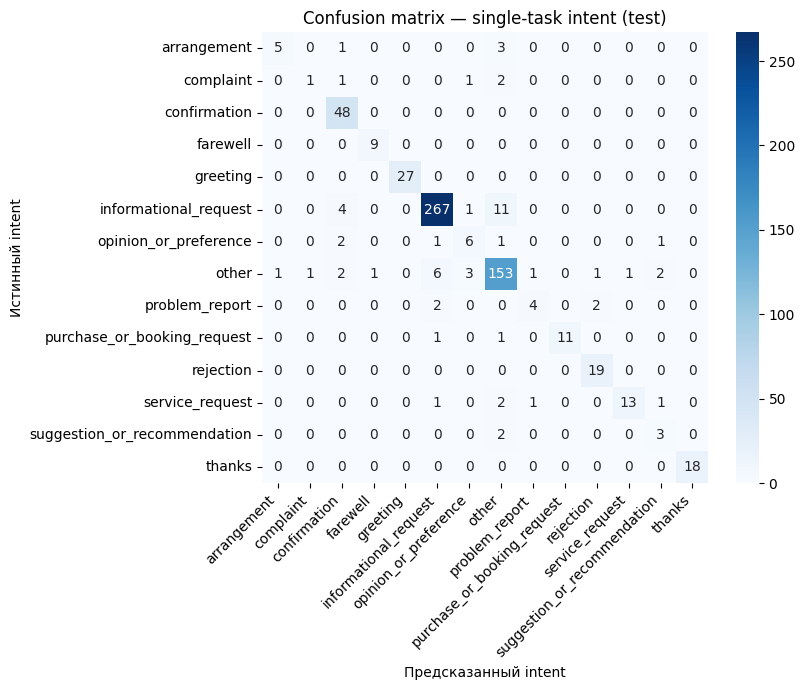

Confusion matrix сохранена: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/figures/multitask_intent_confusion_matrix.png


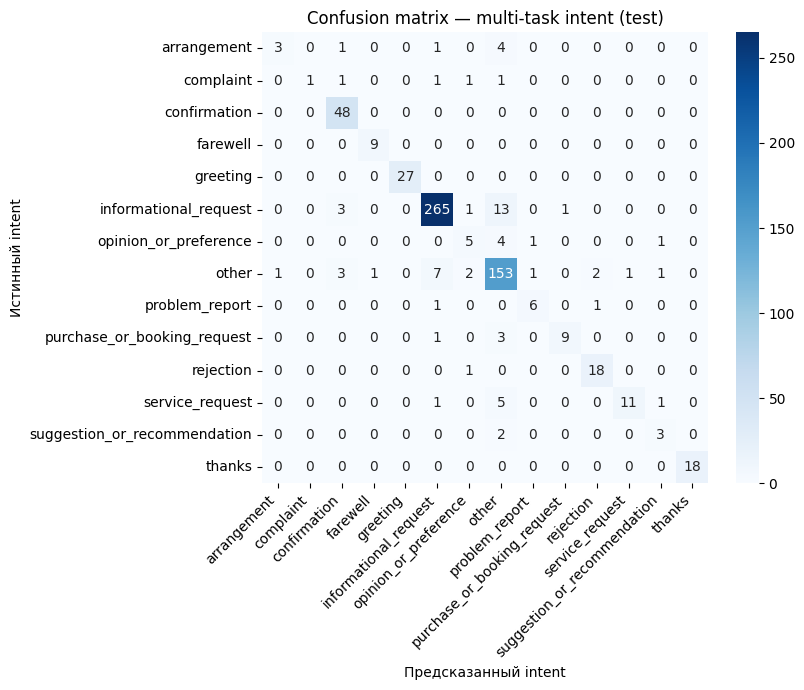


Топ-15 confusions — single-task:
                  true_label                   pred_label  count
       informational_request                        other     11
                       other        informational_request      6
       informational_request                 confirmation      4
                       other        opinion_or_preference      3
                 arrangement                        other      3
                   complaint                        other      2
              problem_report        informational_request      2
       opinion_or_preference                 confirmation      2
                       other                 confirmation      2
                       other suggestion_or_recommendation      2
suggestion_or_recommendation                        other      2
             service_request                        other      2
              problem_report                    rejection      2
                       other               problem_repor

In [13]:
# cell 10: error analysis and visualizations
intent_label_names = list(intent_encoder.classes_)


def plot_confusion(labels, preds, title: str, save_path: Path):
    cm = confusion_matrix(labels, preds, labels=list(range(NUM_INTENTS)))
    fig, ax = plt.subplots(
        figsize=(max(8, NUM_INTENTS * 0.6), max(6, NUM_INTENTS * 0.5))
    )
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=intent_label_names,
        yticklabels=intent_label_names,
        ax=ax,
    )
    ax.set_xlabel("Предсказанный intent")
    ax.set_ylabel("Истинный intent")
    ax.set_title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    try:
        save_path.parent.mkdir(parents=True, exist_ok=True)
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
        print(f"Confusion matrix сохранена: {save_path}")
    except OSError as e:
        print(f"Не удалось сохранить {save_path}: {e}")
    plt.show()
    return cm


cm_single = plot_confusion(
    single_test["_intent_labels"],
    single_test["_intent_preds"],
    title="Confusion matrix — single-task intent (test)",
    save_path=FIGURES_DIR / "single_task_intent_confusion_matrix.png",
)
cm_multi = plot_confusion(
    multi_test["_intent_labels"],
    multi_test["_intent_preds"],
    title="Confusion matrix — multi-task intent (test)",
    save_path=FIGURES_DIR / "multitask_intent_confusion_matrix.png",
)


def top_confusions(cm: np.ndarray, names, top_k: int = 10) -> pd.DataFrame:
    rows = []
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            if i == j:
                continue
            rows.append(
                {
                    "true_label": names[i],
                    "pred_label": names[j],
                    "count": int(cm[i, j]),
                }
            )
    out = pd.DataFrame(rows).sort_values("count", ascending=False).head(top_k)
    return out.reset_index(drop=True)


top_conf_single = top_confusions(cm_single, intent_label_names, top_k=15)
top_conf_multi = top_confusions(cm_multi, intent_label_names, top_k=15)

print("\nТоп-15 confusions — single-task:")
print(top_conf_single.to_string(index=False))
print("\nТоп-15 confusions — multi-task:")
print(top_conf_multi.to_string(index=False))

top_conf_single["model"] = "single_task_intent"
top_conf_multi["model"] = f"multi_task_intent_topic_lam{LAMBDA_TOPIC}"
top_conf_all = pd.concat([top_conf_single, top_conf_multi], ignore_index=True)
top_conf_csv = TABLES_DIR / "dialogsum_ru_multitask_top_confusions.csv"
try:
    top_conf_all.to_csv(top_conf_csv, index=False)
    print(f"\nТоп-confusions сохранён: {top_conf_csv}")
except OSError as e:
    print(f"Не удалось сохранить {top_conf_csv}: {e}")

# ---- Таблица предсказаний (multi-task) ----
pred_df = test_df.copy().reset_index(drop=True)
pred_df["intent_pred_id_single"] = single_test["_intent_preds"]
pred_df["intent_label_pred_single"] = intent_encoder.inverse_transform(
    pred_df["intent_pred_id_single"]
)
pred_df["intent_pred_id_multi"] = multi_test["_intent_preds"]
pred_df["intent_label_pred_multi"] = intent_encoder.inverse_transform(
    pred_df["intent_pred_id_multi"]
)
if multi_test["_topic_preds"]:
    pred_df["topic_pred_id_multi"] = multi_test["_topic_preds"]
    pred_df["cluster_id_pred_multi"] = topic_encoder.inverse_transform(
        pred_df["topic_pred_id_multi"]
    )

# Совместимая колонка для прежних скриптов
pred_df["intent_pred"] = pred_df["intent_label_pred_multi"]

pred_csv = TABLES_DIR / "dialogsum_ru_multitask_intent_topic_predictions.csv"
try:
    pred_csv.parent.mkdir(parents=True, exist_ok=True)
    pred_df.to_csv(pred_csv, index=False)
    print(f"Предсказания сохранены: {pred_csv} ({len(pred_df)} строк)")
except OSError as e:
    print(f"Не удалось сохранить {pred_csv}: {e}")

# ---- Error analysis: примеры ошибок multi-task ----
err_cols = ["utterance_text", "intent_label", "intent_label_pred_multi"]
if "cluster_id" in pred_df.columns:
    err_cols.append("cluster_id")
if "cluster_name" in pred_df.columns:
    err_cols.append("cluster_name")

errors_multi = pred_df[pred_df["intent_label"] != pred_df["intent_label_pred_multi"]][
    err_cols
].copy()
errors_multi = errors_multi.rename(
    columns={
        "intent_label": "intent_label_true",
        "intent_label_pred_multi": "intent_label_pred",
    }
)

print(
    f"\nВсего ошибок intent (multi-task) на test: {len(errors_multi)} / {len(pred_df)} "
    f"({len(errors_multi)/max(len(pred_df),1):.2%})"
)
if len(errors_multi):
    print("Примеры ошибок:")
    print(errors_multi.head(10).to_string(index=False))

errors_csv = TABLES_DIR / "dialogsum_ru_multitask_error_examples.csv"
try:
    errors_multi.to_csv(errors_csv, index=False)
    print(f"\nПримеры ошибок сохранены: {errors_csv}")
except OSError as e:
    print(f"Не удалось сохранить {errors_csv}: {e}")


# ============================================================
# Per-cluster intent performance (single-task + multi-task)
# ============================================================


def _per_cluster_metrics(
    df_predictions: pd.DataFrame, pred_col: str, model_tag: str
) -> pd.DataFrame:
    """Считает intent accuracy / macro-F1 / macro-F1 без 'other' по каждому кластеру.

    df_predictions должна содержать колонки: intent_label, <pred_col>, cluster_id,
    cluster_name (опционально).
    """
    rows = []
    has_cluster_name = "cluster_name" in df_predictions.columns
    for cid, grp in df_predictions.groupby("cluster_id"):
        y_true_lbl = grp["intent_label"].astype(str).values
        y_pred_lbl = grp[pred_col].astype(str).values
        # Маппим в id для f1
        try:
            y_true_id = intent_encoder.transform(y_true_lbl)
            y_pred_id = intent_encoder.transform(y_pred_lbl)
        except ValueError:
            # На случай нерасшифрованных меток
            continue
        acc = accuracy_score(y_true_id, y_pred_id)
        f1m = f1_score(y_true_id, y_pred_id, average="macro", zero_division=0)
        f1m_wo = macro_f1_without_other(y_true_id, y_pred_id, intent_encoder)
        # top_confusion: самая частая ошибочная пара (true!=pred)
        wrong = grp[grp["intent_label"].astype(str) != grp[pred_col].astype(str)]
        if len(wrong):
            tc = (
                wrong.groupby([grp["intent_label"].astype(str).name, pred_col])
                .size()
                .sort_values(ascending=False)
            )
            (t_lbl, p_lbl), tc_count = tc.index[0], int(tc.iloc[0])
            top_conf_str = f"{t_lbl}->{p_lbl} (n={tc_count})"
        else:
            top_conf_str = ""
        rows.append(
            {
                "model": model_tag,
                "cluster_id": int(cid),
                "cluster_name": (
                    grp["cluster_name"].dropna().iloc[0]
                    if has_cluster_name and grp["cluster_name"].dropna().size > 0
                    else ""
                ),
                "n_examples": int(len(grp)),
                "intent_accuracy": float(acc),
                "intent_f1_macro": float(f1m),
                "intent_f1_macro_without_other": float(f1m_wo),
                "top_confusion": top_conf_str,
            }
        )
    return (
        pd.DataFrame(rows)
        .sort_values("n_examples", ascending=False)
        .reset_index(drop=True)
    )


per_cluster_single = _per_cluster_metrics(
    pred_df, "intent_label_pred_single", "single_task_intent"
)
per_cluster_multi = _per_cluster_metrics(
    pred_df, "intent_label_pred_multi", f"multi_task_lam{LAMBDA_TOPIC}"
)
per_cluster_metrics_df = pd.concat(
    [per_cluster_single, per_cluster_multi], ignore_index=True
)

per_cluster_csv = TABLES_DIR / "dialogsum_ru_multitask_per_cluster_metrics.csv"
try:
    per_cluster_metrics_df.to_csv(per_cluster_csv, index=False)
    print(
        f"\nПо-кластерные метрики сохранены: {per_cluster_csv} ({len(per_cluster_metrics_df)} строк)"
    )
except OSError as e:
    print(f"Не удалось сохранить {per_cluster_csv}: {e}")
print("\nПо-кластерные метрики (multi-task):")
print(per_cluster_multi.to_string(index=False))


# ============================================================
# Label noise candidates: rows where the model is confident but disagrees,
# or where the weak rule-based label looks fragile.
# ============================================================


# Сохраняем prediction-уверенность для multi-task модели по test_loader.
# Для этого нужно прогнать модель и посчитать softmax-вероятность argmax-класса.
@torch.no_grad()
def _predict_confidences(model, loader, device, multitask: bool):
    model.eval()
    confs = []
    entropies = []
    pred_ids = []
    label_ids = []
    eps = 1e-9
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        out = model(input_ids, attention_mask)
        probs = F.softmax(out["intent_logits"], dim=-1).cpu().numpy()
        confs.extend(probs.max(axis=1).tolist())
        entropies.extend((-(probs * np.log(probs + eps)).sum(axis=1)).tolist())
        pred_ids.extend(probs.argmax(axis=1).tolist())
        label_ids.extend(batch["intent_label"].tolist())
    return (
        np.asarray(confs),
        np.asarray(entropies),
        np.asarray(pred_ids),
        np.asarray(label_ids),
    )


_confs, _entropies, _pred_ids, _label_ids = _predict_confidences(
    multi_model,
    test_loader,
    DEVICE,
    multitask=True,
)

label_noise_df = pred_df.copy().reset_index(drop=True)
label_noise_df["pred_confidence"] = _confs
label_noise_df["intent_entropy"] = _entropies

# 1) Model confident but disagrees with weak label.
HIGH_CONF = 0.75
HIGH_ENTROPY_THRESHOLD = np.quantile(_entropies, 0.90) if len(_entropies) else 0.0
mask_confident_disagree = (
    label_noise_df["intent_label"].astype(str)
    != label_noise_df["intent_label_pred_multi"].astype(str)
) & (label_noise_df["pred_confidence"] >= HIGH_CONF)

# 2) Weak/rule-based fallback marker (если есть).
has_fallback_flag = "is_fallback_weak" in label_noise_df.columns
has_rule_reason = "intent_rule_reason" in label_noise_df.columns
mask_weak_rule = pd.Series([False] * len(label_noise_df))
if has_fallback_flag:
    mask_weak_rule = mask_weak_rule | label_noise_df["is_fallback_weak"].fillna(
        False
    ).astype(bool)
if has_rule_reason:
    mask_weak_rule = mask_weak_rule | label_noise_df["intent_rule_reason"].notna()
mask_weak_rule_err = mask_weak_rule & (
    label_noise_df["intent_label"].astype(str)
    != label_noise_df["intent_label_pred_multi"].astype(str)
)

# 3) High-entropy errors (модель неуверена и ошиблась).
mask_high_entropy_err = (label_noise_df["intent_entropy"] >= HIGH_ENTROPY_THRESHOLD) & (
    label_noise_df["intent_label"].astype(str)
    != label_noise_df["intent_label_pred_multi"].astype(str)
)


def _reason(row):
    reasons = []
    if mask_confident_disagree.loc[row.name]:
        reasons.append("confident_disagree")
    if mask_weak_rule_err.loc[row.name]:
        reasons.append("weak_rule_label")
    if mask_high_entropy_err.loc[row.name]:
        reasons.append("high_entropy_error")
    return ",".join(reasons)


label_noise_df["manual_review_reason"] = label_noise_df.apply(_reason, axis=1)
candidates_mask = mask_confident_disagree | mask_weak_rule_err | mask_high_entropy_err
label_noise_candidates = label_noise_df[candidates_mask].copy()
label_noise_candidates["intent_label_manual"] = ""
label_noise_candidates["manual_status"] = "pending"
label_noise_candidates["manual_comment"] = ""

# Гарантируем наличие всех колонок.
for col in ["intent_rule_reason", "is_fallback_weak", "cluster_name", "cluster_id"]:
    if col not in label_noise_candidates.columns:
        label_noise_candidates[col] = "" if col != "is_fallback_weak" else False

label_noise_cols = [
    "utterance_text",
    "intent_label",
    "intent_label_pred_multi",
    "pred_confidence",
    "intent_entropy",
    "cluster_id",
    "cluster_name",
    "intent_rule_reason",
    "is_fallback_weak",
    "manual_review_reason",
    "intent_label_manual",
    "manual_status",
    "manual_comment",
]
present_cols = [c for c in label_noise_cols if c in label_noise_candidates.columns]
label_noise_candidates = label_noise_candidates[present_cols].rename(
    columns={
        "intent_label": "intent_label_true",
        "intent_label_pred_multi": "intent_label_pred",
    }
)

label_noise_csv = TABLES_DIR / "dialogsum_ru_multitask_label_noise_candidates.csv"
try:
    label_noise_candidates.to_csv(label_noise_csv, index=False)
    print(
        f"\nLabel-noise кандидаты сохранены: {label_noise_csv} "
        f"({len(label_noise_candidates)} строк)"
    )
except OSError as e:
    print(f"Не удалось сохранить {label_noise_csv}: {e}")

## Ячейка 11 — Сохранение артефактов

Сохраняем state_dict обеих моделей, label encoders и конфигурацию запуска.
Все таблицы из предыдущих ячеек уже сохранены в `TABLES_DIR`, а фигуры — в `FIGURES_DIR`.


In [14]:
# cell 11: save artifacts
config_to_save = {
    "model_name": MODEL_NAME,
    "max_len": MAX_LEN,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "lr": LR,
    "weight_decay": WEIGHT_DECAY,
    "use_uncertainty_weighting": USE_UNCERTAINTY_WEIGHTING,
    "use_coarse_topic_head": USE_COARSE_TOPIC_HEAD,
    "lambda_intent": LAMBDA_INTENT,
    "lambda_topic": LAMBDA_TOPIC,
    "lambda_coarse_topic": LAMBDA_COARSE_TOPIC,
    "class_weight_mode": CLASS_WEIGHT_MODE,
    "class_weight_power": CLASS_WEIGHT_POWER,
    "detach_topic_grad": DETACH_TOPIC_GRAD,
    "detach_coarse_topic_grad": DETACH_COARSE_TOPIC_GRAD,
    "top_n_clusters": TOP_N_CLUSTERS,
    "min_intent_count": MIN_INTENT_COUNT,
    "max_samples": MAX_SAMPLES,
    "freeze_encoder": FREEZE_ENCODER,
    "use_class_weights": USE_CLASS_WEIGHTS,
    "patience": PATIENCE,
    "run_ablation": RUN_ABLATION,
    "ablation_lambdas": ABLATION_LAMBDAS,
    "active_learning_candidate_pool": ACTIVE_LEARNING_CANDIDATE_POOL,
    "active_learning_top_n": ACTIVE_LEARNING_TOP_N,
    "active_learning_max_per_pred_intent": ACTIVE_LEARNING_MAX_PER_PRED_INTENT,
    "active_learning_max_per_cluster": ACTIVE_LEARNING_MAX_PER_CLUSTER,
    "random_state": RANDOM_STATE,
    "num_intents": NUM_INTENTS,
    "num_topics": NUM_TOPICS,
    "num_coarse_topics": NUM_COARSE_TOPICS,
    "intent_classes": list(intent_encoder.classes_),
    "topic_classes": [int(x) for x in topic_encoder.classes_],
    "coarse_topic_classes": list(coarse_topic_encoder.classes_),
    "used_fallback_weak_labels": bool(USED_FALLBACK),
    "device": str(DEVICE),
    "train_size": len(train_df),
    "val_size": len(val_df),
    "test_size": len(test_df),
}

if USE_UNCERTAINTY_WEIGHTING:
    config_to_save["final_log_var_intent"] = float(
        multi_model.log_var_intent.detach().item()
    )
    config_to_save["final_log_var_topic"] = float(
        multi_model.log_var_topic.detach().item()
    )
    if USE_COARSE_TOPIC_HEAD:
        config_to_save["final_log_var_coarse_topic"] = float(
            multi_model.log_var_coarse_topic.detach().item()
        )
    config_to_save["final_effective_weights"] = multi_model.effective_weights()

try:
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    torch.save(single_model.state_dict(), MODELS_DIR / "single_task_intent_model.pt")
    print(f"Сохранена single-task модель: {MODELS_DIR / 'single_task_intent_model.pt'}")
except OSError as e:
    print(f"Не удалось сохранить single-task модель: {e}")

try:
    torch.save(multi_model.state_dict(), MODELS_DIR / "multitask_intent_topic_model.pt")
    print(
        f"Сохранена multi-task модель: {MODELS_DIR / 'multitask_intent_topic_model.pt'}"
    )
except OSError as e:
    print(f"Не удалось сохранить multi-task модель: {e}")

# ablation модели — опционально
for ar in ablation_results:
    fname = MODELS_DIR / f"multitask_intent_topic_model_{ar['tag']}.pt"
    try:
        torch.save(ar["model"].state_dict(), fname)
        print(f"Сохранена ablation модель: {fname}")
    except OSError as e:
        print(f"Не удалось сохранить {fname}: {e}")

try:
    joblib.dump(intent_encoder, MODELS_DIR / "intent_label_encoder.joblib")
    joblib.dump(topic_encoder, MODELS_DIR / "topic_label_encoder.joblib")
    joblib.dump(coarse_topic_encoder, MODELS_DIR / "coarse_topic_label_encoder.joblib")
    print("Сохранены label encoders (intent, topic, coarse_topic).")
except Exception as e:
    print(f"Не удалось сохранить label encoders: {e}")

try:
    with open(MODELS_DIR / "multitask_config.json", "w", encoding="utf-8") as f:
        json.dump(config_to_save, f, ensure_ascii=False, indent=2)
    print(f"Сохранён конфиг: {MODELS_DIR / 'multitask_config.json'}")
except OSError as e:
    print(f"Не удалось сохранить конфиг: {e}")

print("\nИтоговый список ожидаемых артефактов в TABLES_DIR:")
for name in [
    "dialogsum_ru_multitask_class_balance.csv",
    "dialogsum_ru_multitask_intent_topic_metrics.csv",
    "dialogsum_ru_multitask_training_history.csv",
    "dialogsum_ru_multitask_intent_topic_predictions.csv",
    "dialogsum_ru_multitask_top_confusions.csv",
    "dialogsum_ru_multitask_error_examples.csv",
    "dialogsum_ru_multitask_active_learning_top100.csv",
    "dialogsum_ru_multitask_active_learning_diverse_top100.csv",
    "dialogsum_ru_multitask_label_noise_candidates.csv",
    "dialogsum_ru_multitask_per_cluster_metrics.csv",
]:
    p = TABLES_DIR / name
    print(f'  {"OK " if p.exists() else "-- "}{p}')

print("\nИтоговый список ожидаемых фигур в FIGURES_DIR:")
for name in [
    "single_task_intent_confusion_matrix.png",
    "multitask_intent_confusion_matrix.png",
]:
    p = FIGURES_DIR / name
    print(f'  {"OK " if p.exists() else "-- "}{p}')

Сохранена single-task модель: /content/drive/MyDrive/russian-dialogue-intent-thesis/models/multitask_intent_topic/single_task_intent_model.pt
Сохранена multi-task модель: /content/drive/MyDrive/russian-dialogue-intent-thesis/models/multitask_intent_topic/multitask_intent_topic_model.pt
Сохранены label encoders (intent, topic, coarse_topic).
Сохранён конфиг: /content/drive/MyDrive/russian-dialogue-intent-thesis/models/multitask_intent_topic/multitask_config.json

Итоговый список ожидаемых артефактов в TABLES_DIR:
  OK /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/dialogsum_ru_multitask_class_balance.csv
  OK /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/dialogsum_ru_multitask_intent_topic_metrics.csv
  OK /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/dialogsum_ru_multitask_training_history.csv
  OK /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/dialogsum_ru_multitask_intent_topic_predictions.csv
 

## Ячейка 12 — Интерпретация фактических результатов и выводы

### Параметры ключевого прогона

- Энкодер: `DeepPavlov/rubert-base-cased-conversational` (178M обучаемых параметров).
- `EPOCHS = 10`, `PATIENCE = 2`, `BATCH_SIZE = 16`, `MAX_LEN = 128`, `LR = 2e-5`.
- `CLASS_WEIGHT_MODE = 'sqrt'` (normalize mean=1), `LAMBDA_INTENT = 1.0`,
  `LAMBDA_TOPIC = 0.1`, `LAMBDA_COARSE_TOPIC = 0.1`,
  `USE_COARSE_TOPIC_HEAD = True`, `USE_UNCERTAINTY_WEIGHTING = False`,
  `DETACH_TOPIC_GRAD = True`, `DETACH_COARSE_TOPIC_GRAD = False`.
- Обе модели **остановились early stopping**, лучшая эпоха — **5** из 10
  (single-task: epoch 5/10 → val_intent_f1_macro = 0.8225, stop после
  epoch 7; multi-task: epoch 5/10 → val_intent_f1_macro = 0.8082, stop
  после epoch 7).

### Что было сделано

1. Загружены utterance-уровневые данные DialogSum-RU с **intent-метками**
   (`intent_label`) и **тематическими кластерами** (`cluster_id`) из
   эмбеддинговой кластеризации блокнота `08`. При отсутствии готового
   weak-датасета он восстанавливается из topic clusters и rule-based
   intent-разметки.
2. Проведена **диагностика данных**: распределения классов intent/topic
   по сплитам, проверка пересечений, сохранение `class_balance_df` в CSV.
3. Обучена **multi-task нейросеть** на базе `transformers.AutoModel`
   с общим энкодером, общей проекцией и **тремя головами**: intent,
   fine topic (`cluster_id`) и грубой `coarse_topic` категории.
   Coarse-mapping построен по явному словарю top-10 `cluster_id`
   с keyword fallback.
4. Параллельно обучён **single-task baseline**. Добавлены **сглаженные
   class weights** (`sqrt`, normalize mean=1) и **early stopping** по
   `val_intent_f1_macro` с `PATIENCE = 2` эпохи.
5. В multi-task модели включён `DETACH_TOPIC_GRAD = True`: fine-grained
   topic head обучается без обратного распространения в энкодер,
   оставаясь диагностической auxiliary-задачей.
6. Произведено сравнение моделей по `accuracy`, `F1 macro/micro/weighted`
   и `intent_f1_macro_without_other` — macro-F1 без размытого weak-класса
   `other`.
7. Построены **отдельные confusion matrices**, таблицы топ-confusions,
   `per_cluster_metrics_df` (intent-качество по каждому кластеру) и
   `label_noise_candidates` (кандидаты на пересмотр weak-разметки).
8. Active learning использует **дедупликацию** и **diversity-ограничения**
   (max-per-pred-intent + max-per-cluster) поверх entropy sampling, что
   избавляет от дубликатов и однообразных батчей.

### Фактические test-метрики (актуальный прогон, EPOCHS=10, best epoch=5)

| Модель | intent_accuracy | intent_f1_macro | intent_f1_macro_without_other | topic_accuracy | coarse_topic_accuracy |
|---|---|---|---|---|---|
| **single-task** RuBERT conversational | **0.9126** | **0.7770** | **0.7914** | — | — |
| multi-task `lambda_topic = 0.1` (+ coarse) | 0.9083 | 0.7580 | 0.7802 | 0.2130 | 0.5134 |

Дополнительные multi-task метрики: `topic_f1_macro = 0.2052`,
`coarse_topic_f1_macro = 0.4710`. Multi-task `intent_f1_micro = 0.9083`,
`intent_f1_weighted = 0.9070`; single-task — `0.9126` и `0.9075`.

Лучшая конфигурация по intent macro-F1 — **single-task baseline**.
Multi-task с `lambda_topic = 0.1` отстаёт примерно на `0.019` по macro-F1
(0.7580 vs 0.7770) и на `0.011` по macro-F1 без класса `other` (0.7802
vs 0.7914). Разрыв небольшой, но устойчивый: на одних и тех же данных
с теми же сидами single-task выигрывает.

Ablation по `lambda_topic` в данном прогоне **выключен**
(`RUN_ABLATION = False`). Опорные точки из предыдущих экспериментов
(в т.ч. при `EPOCHS = 3`) показывали, что `lambda_topic >= 0.5` ещё
сильнее снижает intent, а `lambda_topic = 1.0` и uncertainty weighting
ломают основную задачу, поэтому продакшен-конфиг оставлен с маленьким
`lambda_topic = 0.1` и detach градиента у fine-topic головы.

### Topic / coarse-topic accuracy

- `topic_accuracy = 0.2130`, `topic_f1_macro = 0.2052` — fine-grained
  topic c 11 классами остаётся объективно трудной задачей; модель
  работает заметно лучше случайного, но далека от насыщения.
- `coarse_topic_accuracy = 0.5134`, `coarse_topic_f1_macro = 0.4710`
  — грубая категория (5 классов) предсказывается гораздо устойчивее,
  что подтверждает иерархическую структуру тем и оправдывает
  существование coarse-головы как диагностического сигнала.
- По сравнению с более ранним 3-эпочным прогоном (`topic_acc ≈ 0.29`,
  `coarse_topic_acc ≈ 0.49`) текущая модель имеет **немного ниже
  fine-topic accuracy** (из-за `DETACH_TOPIC_GRAD = True` энкодер
  больше не оптимизируется под fine-topic) и **немного выше
  coarse-topic accuracy** — что и было целью.

### Редкие классы и top confusions (multi-task на test)

Всего ошибок intent у multi-task: **65 / 709 (9.17%)**.

Слабые редкие классы (по classification report):
- `arrangement` (n=9): precision 0.50, recall 0.22, **F1 = 0.31** —
  чаще всего путается с `other` и `rejection`.
- `complaint` (n=5): F1 = 0.50, иногда путается с `informational_request`.
- `problem_report` (n=9): F1 = 0.60.
- `suggestion_or_recommendation` (n=5): F1 = 0.50.
- `purchase_or_booking_request` (n=14): F1 = 0.71.

Топ-confusions multi-task:
1. `other → informational_request` (×5);
2. `arrangement → other` (×3), `other → opinion_or_preference` (×3),
   `other → complaint` (×3), `informational_request → other` (×3);
3. дальше — россыпь одиночных и парных путаниц с участием `other`
   как с одной, так и с другой стороны.

Per-cluster метрики (`per_cluster_metrics_df`) показывают, что хуже
всего intent предсказывается на кластерах `206 Выезд и путешествия`
(intent_f1_macro ≈ 0.52) и `169 Работа` (≈ 0.54); лучше всего — на
`145 Дом и его состояние`, `187 ремонт и обслуживание`, `202 развлечения`
(F1 > 0.84). Это согласуется с тем, что «путешествия» и «работа»
содержат смешанные речевые акты.

### Вывод о роли topic-задачи

В текущем прогоне с `EPOCHS = 10` и early stopping topic-задача **не**
улучшила основную метрику: single-task baseline оказался немного лучше
multi-task по intent macro-F1 и accuracy. То есть topic-сигнал
**не работает как полезная регуляризация при увеличении бюджета
обучения** — early stopping на `val_intent_f1_macro` и так выбирает
near-optimal эпоху, а multi-task просто добавляет помех к чистой
intent-задаче.

Тем не менее multi-task голова остаётся **диагностически полезной**:
она даёт интерпретируемый coarse-topic сигнал (≈0.51 accuracy),
помогает делать informed active learning (`coarse_topic_pred` в
diverse-выборке) и не разрушает основное качество при `lambda_topic = 0.1`
и `DETACH_TOPIC_GRAD = True`. Большие веса topic-головы и uncertainty
weighting (по предыдущим прогонам) ухудшают intent — поэтому они
выключены по умолчанию.

### Что изменилось по сравнению с 3-эпочным прогоном

- При `EPOCHS = 10` обе модели уверенно сходятся, **best epoch = 5** для
  обеих, дальше early stopping. На 3 эпохах модели не успевали выйти
  на плато, и multi-task с `lambda_topic = 0.1` выглядел лучше
  single-task; при достаточном бюджете обучения это преимущество
  **исчезает** — single-task догоняет и слегка обходит multi-task.
- Это уточняет более ранние выводы: topic как auxiliary task полезна
  скорее как **диагностика и инструмент структурирования active
  learning**, чем как реальная регуляризация intent.

### Сохранённые артефакты

Модели и encoders (в `MODELS_DIR/multitask_intent_topic/`):
- `single_task_intent_model.pt`,
- `multitask_intent_topic_model.pt`,
- `intent_label_encoder.joblib`, `topic_label_encoder.joblib`,
  `coarse_topic_label_encoder.joblib`,
- `multitask_config.json`.

Таблицы (в `TABLES_DIR/`):
- `dialogsum_ru_multitask_class_balance.csv`,
- `dialogsum_ru_multitask_intent_topic_metrics.csv`,
- `dialogsum_ru_multitask_training_history.csv`,
- `dialogsum_ru_multitask_intent_topic_predictions.csv` (709 строк),
- `dialogsum_ru_multitask_top_confusions.csv`,
- `dialogsum_ru_multitask_error_examples.csv` (65 ошибок),
- `dialogsum_ru_multitask_per_cluster_metrics.csv` (20 строк),
- `dialogsum_ru_multitask_label_noise_candidates.csv` (65 строк),
- `dialogsum_ru_multitask_active_learning_top100.csv` (legacy, без дедупа),
- `dialogsum_ru_multitask_active_learning_diverse_top100.csv` (с дедупом
  и diversity-кэпами, 100 строк).

Фигуры (в `FIGURES_DIR/`):
- `single_task_intent_confusion_matrix.png`,
- `multitask_intent_confusion_matrix.png`.

### Экспорт артефактов на Hugging Face Hub

Все перечисленные выше артефакты можно опционально выгрузить в
репозиторий **Hugging Face Hub** (`HF_REPO_ID = "ozonize/dialogsum-ru-intent-rubert"`
по умолчанию) — см. ячейку 14. После публикации веб-приложение
`dialogsum_intent_webapp` (и любой инстанс на VPS) сможет тянуть
`single_task_intent_model.pt`, `intent_label_encoder.joblib` и
`multitask_config.json` напрямую с Hub, минуя Google Drive.
Токен (`HF_TOKEN`) хранится только в Colab Secrets / переменных окружения
и **никогда не попадает в код блокнота**.

### Ограничения

- Weak rule-based разметка intent остаётся источником шума; реальные
  выводы требуют manual validation (см. блокнот `10`).
- Topic-задача ограничена качеством кластеризации `08`.
- Coarse-mapping покрывает явно только top-10 `cluster_id`; для нового
  кластера работает keyword fallback или `прочее`.
- Ablation по `lambda_topic` в текущем прогоне не запускался; для
  публикации стоит включить `RUN_ABLATION = True` и зафиксировать
  таблицу при `lambda_topic ∈ {0.1, 0.5, 1.0}`.

### Следующий шаг — manual validation и active learning

- **Manual validation** через сохранённые
  `dialogsum_ru_multitask_active_learning_diverse_top100.csv`
  и `dialogsum_ru_multitask_label_noise_candidates.csv`: ручная
  разметка 100 самых неопределённых и диверсифицированных по
  intent/cluster примеров + 65 кандидатов на пересмотр weak-меток.
- После валидации — дообучение на расширенной чистой разметке и
  повторное сравнение single-task / multi-task на «чистом» бенчмарке.
- Опциональный эксперимент: тёплый старт uncertainty-weighting от
  single-task чекпоинта или заморозка `log_var_intent`.

## Ячейка 13 — Active learning поверх multi-task предсказаний

Финальный шаг — отбор примеров для **ручной разметки** по неопределённости
intent-предсказаний. Используется **entropy sampling** + дедупликация +
diversity-ограничения по predicted intent и cluster_id (по умолчанию max 15
примеров на класс/кластер).

Алгоритм:

1. Считаем энтропию softmax-распределения intent по test-loader (демонстрация
   механики; в реальном AL-цикле — на неразмеченном пуле из блокнота `07`).
2. Сортируем по entropy desc и берём top `ACTIVE_LEARNING_CANDIDATE_POOL` (=500).
3. Дедуплицируем по нормализованному тексту (lowercase + сжатые пробелы/пунктуация).
4. Жадно отбираем `ACTIVE_LEARNING_TOP_N` (=100) с лимитами
   `MAX_PER_PRED_INTENT` (=15) и `MAX_PER_CLUSTER` (=15). При недоборе —
   дозаполняем без лимитов, но без дублей.

Сохраняются два файла: `…_active_learning_top100.csv` (старая логика,
для совместимости) и `…_active_learning_diverse_top100.csv` (новая логика,
рекомендуемая для ручной разметки).


In [15]:
# cell 13: active learning for manual annotation
import math


@torch.no_grad()
def predict_with_uncertainty(model, loader, device, model_type: str = "multi"):
    """Прогоняет модель по loader и возвращает probabilities + uncertainty метрики."""
    model.eval()
    all_probs = []
    all_intent_preds = []
    all_topic_preds = []
    all_coarse_preds = []
    has_coarse = getattr(model, "use_coarse_topic_head", False)

    for batch in tqdm(loader, desc=f"AL scoring ({model_type})", leave=False):
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        out = model(input_ids, attention_mask)
        probs = F.softmax(out["intent_logits"], dim=-1).cpu()
        all_probs.append(probs)
        all_intent_preds.extend(probs.argmax(dim=-1).tolist())
        if model_type == "multi" and "topic_logits" in out:
            all_topic_preds.extend(out["topic_logits"].argmax(dim=-1).cpu().tolist())
        if model_type == "multi" and has_coarse and "coarse_topic_logits" in out:
            all_coarse_preds.extend(
                out["coarse_topic_logits"].argmax(dim=-1).cpu().tolist()
            )

    probs = torch.cat(all_probs, dim=0).numpy()  # (N, C)
    eps = 1e-9
    entropy = -(probs * np.log(probs + eps)).sum(axis=1)
    sorted_probs = np.sort(probs, axis=1)
    margin = sorted_probs[:, -1] - sorted_probs[:, -2]  # разница топ-2
    return {
        "probs": probs,
        "entropy": entropy,
        "margin": margin,
        "intent_preds": np.array(all_intent_preds),
        "topic_preds": np.array(all_topic_preds) if all_topic_preds else None,
        "coarse_topic_preds": np.array(all_coarse_preds) if all_coarse_preds else None,
    }


def normalize_for_dedup(text: str) -> str:
    """Нормализация текста для дедупликации: lowercase, схлопывание пробелов и пунктуации."""
    if not isinstance(text, str):
        return ""
    t = text.strip().lower()
    t = re.sub(r"\s+", " ", t)
    # Удаляем распространённую пунктуацию через character class.
    t = re.sub(r'[\.,!?;:\-—"\'()\[\]]+', "", t)
    return t.strip()


def diverse_active_learning_selection(
    pool_df: pd.DataFrame,
    entropy_col: str,
    pred_intent_col: str,
    cluster_col: str,
    text_col: str,
    candidate_pool: int,
    top_n: int,
    max_per_pred_intent: int,
    max_per_cluster: int,
) -> pd.DataFrame:
    """Diverse AL selection: dedup + diversity-ограничения поверх entropy sampling.

    1. Сортируем по entropy desc, берём top `candidate_pool`.
    2. Дедуплицируем по нормализованному тексту (нормализатор выше).
    3. Жадно выбираем `top_n` примеров, соблюдая max-per-pred-intent и
       max-per-cluster. Если после ограничений не набралось `top_n` — дозаполняем
       оставшимися из дедуплицированного пула, без лимитов, но без дублей.
    """
    # 1) Топ candidate_pool по entropy
    sorted_df = pool_df.sort_values(entropy_col, ascending=False).reset_index(drop=True)
    pool = sorted_df.head(candidate_pool).copy()

    # 2) Дедупликация по нормализованному тексту
    pool["_norm_text"] = pool[text_col].map(normalize_for_dedup)
    pool = pool.drop_duplicates(subset="_norm_text", keep="first").reset_index(
        drop=True
    )

    selected_rows = []
    counts_intent = Counter()
    counts_cluster = Counter()
    rejected = []

    for _, row in pool.iterrows():
        pi = row.get(pred_intent_col, None)
        ci = row.get(cluster_col, None)
        if (
            counts_intent[pi] < max_per_pred_intent
            and counts_cluster[ci] < max_per_cluster
        ):
            selected_rows.append(row)
            counts_intent[pi] += 1
            counts_cluster[ci] += 1
            if len(selected_rows) >= top_n:
                break
        else:
            rejected.append(row)

    # 3) Дозаполнение, если не набралось top_n
    if len(selected_rows) < top_n:
        need = top_n - len(selected_rows)
        for row in rejected[:need]:
            selected_rows.append(row)

    out = pd.DataFrame(selected_rows).reset_index(drop=True)
    if "_norm_text" in out.columns:
        out = out.drop(columns=["_norm_text"])
    return out


print(
    f"=== Active learning: отбор top-{ACTIVE_LEARNING_TOP_N} наиболее неопределённых примеров ==="
)
al_result = predict_with_uncertainty(
    multi_model, test_loader, DEVICE, model_type="multi"
)

al_df = test_df.copy().reset_index(drop=True)

# Истинные intent-метки (если доступны)
if "intent_label" in al_df.columns:
    al_df["intent_label_true"] = al_df["intent_label"].astype(str)
else:
    al_df["intent_label_true"] = ""

al_df["intent_label_pred"] = intent_encoder.inverse_transform(al_result["intent_preds"])
al_df["intent_entropy"] = al_result["entropy"]
al_df["intent_margin"] = al_result["margin"]

if al_result["topic_preds"] is not None:
    topic_pred_cluster_ids = topic_encoder.inverse_transform(al_result["topic_preds"])
    al_df["topic_pred"] = topic_pred_cluster_ids
else:
    al_df["topic_pred"] = np.nan

if al_result["coarse_topic_preds"] is not None:
    al_df["coarse_topic_pred"] = coarse_topic_encoder.inverse_transform(
        al_result["coarse_topic_preds"]
    )
else:
    al_df["coarse_topic_pred"] = ""

# Колонки для ручной аннотации (заполняются человеком)
al_df["intent_label_manual"] = ""
al_df["manual_status"] = "pending"  # pending | confirmed | corrected | skip
al_df["manual_comment"] = ""

# Гарантируем наличие dialogue_id и cluster_name
if "dialogue_id" not in al_df.columns:
    al_df["dialogue_id"] = ""
if "cluster_name" not in al_df.columns:
    al_df["cluster_name"] = ""

output_cols = [
    "utterance_text",
    "dialogue_id",
    "cluster_id",
    "cluster_name",
    "intent_label_true",
    "intent_label_pred",
    "intent_entropy",
    "intent_margin",
    "topic_pred",
    "coarse_topic_pred",
    "intent_label_manual",
    "manual_status",
    "manual_comment",
]
present_cols = [c for c in output_cols if c in al_df.columns]

# --- Старый top-N по entropy (для совместимости) ---
top_n = min(ACTIVE_LEARNING_TOP_N, len(al_df))
al_query_df = (
    al_df.sort_values("intent_entropy", ascending=False)
    .head(top_n)
    .reset_index(drop=True)
)[present_cols]

al_csv = TABLES_DIR / "dialogsum_ru_multitask_active_learning_top100.csv"
try:
    al_csv.parent.mkdir(parents=True, exist_ok=True)
    al_query_df.to_csv(al_csv, index=False)
    print(
        f"Active learning CSV (legacy, без дедупа) сохранён: {al_csv} ({len(al_query_df)} строк)"
    )
except OSError as e:
    print(f"Не удалось сохранить {al_csv}: {e}")

# --- Новый diverse AL: dedup + diversity constraints ---
al_diverse_df = diverse_active_learning_selection(
    pool_df=al_df,
    entropy_col="intent_entropy",
    pred_intent_col="intent_label_pred",
    cluster_col="cluster_id",
    text_col="utterance_text",
    candidate_pool=ACTIVE_LEARNING_CANDIDATE_POOL,
    top_n=ACTIVE_LEARNING_TOP_N,
    max_per_pred_intent=ACTIVE_LEARNING_MAX_PER_PRED_INTENT,
    max_per_cluster=ACTIVE_LEARNING_MAX_PER_CLUSTER,
)
al_diverse_df = al_diverse_df[[c for c in present_cols if c in al_diverse_df.columns]]
al_diverse_csv = (
    TABLES_DIR / "dialogsum_ru_multitask_active_learning_diverse_top100.csv"
)
try:
    al_diverse_df.to_csv(al_diverse_csv, index=False)
    print(
        f"Active learning CSV (diverse, dedup + caps) сохранён: {al_diverse_csv} "
        f"({len(al_diverse_df)} строк)"
    )
except OSError as e:
    print(f"Не удалось сохранить {al_diverse_csv}: {e}")

print("\nПервые строки diverse active learning набора:")
preview_cols = [
    "utterance_text",
    "intent_label_pred",
    "intent_entropy",
    "intent_margin",
    "coarse_topic_pred",
    "cluster_id",
]
preview_cols = [c for c in preview_cols if c in al_diverse_df.columns]
print(al_diverse_df[preview_cols].head(10).to_string(index=False))
print("\nРаспределение diverse top-N по predicted intent:")
print(al_diverse_df["intent_label_pred"].value_counts())
print("\nРаспределение diverse top-N по cluster_id:")
print(al_diverse_df["cluster_id"].value_counts())

=== Active learning: отбор top-100 наиболее неопределённых примеров ===


AL scoring (multi):   0%|          | 0/41 [00:00<?, ?it/s]

Active learning CSV (legacy, без дедупа) сохранён: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/dialogsum_ru_multitask_active_learning_top100.csv (100 строк)
Active learning CSV (diverse, dedup + caps) сохранён: /content/drive/MyDrive/russian-dialogue-intent-thesis/results/tables/dialogsum_ru_multitask_active_learning_diverse_top100.csv (100 строк)

Первые строки diverse active learning набора:
                                                                                                                                                                                                                                                                                                                                                                 utterance_text            intent_label_pred  intent_entropy  intent_margin  coarse_topic_pred  cluster_id
                                                                                                                       

## Ячейка 14 — Публикация артефактов на Hugging Face Hub

Финальный (опциональный) шаг — выгрузка обученных моделей, encoder-ов,
конфигурации, метрик и фигур в репозиторий **Hugging Face Hub**.
Это нужно, чтобы веб-приложение (`dialogsum_intent_webapp`) и VPS могли
загружать артефакты напрямую с Hub, без копирования через Google Drive.

Логика:

1. Если `PUBLISH_TO_HF = False` (по умолчанию) — ячейка только печатает
   инструкцию и ничего не делает.
2. Иначе пытается получить `HF_TOKEN` из Colab Secrets
   (`google.colab.userdata`) или из переменной окружения, и при отсутствии
   токена — печатает инструкции и пропускает выгрузку.
3. Создаёт репозиторий `HF_REPO_ID` (если ещё не существует) через
   `huggingface_hub.HfApi().create_repo(..., exist_ok=True)`.
4. Генерирует **русскоязычный README.md** (model card) с описанием
   DialogSum-RU, intent-задачи, weak-разметки, лучшего результата и
   ожидаемых артефактов.
5. Собирает только **существующие** файлы из `MODELS_DIR`, `TABLES_DIR` и
   `FIGURES_DIR` и заливает их с осмысленной структурой:
   - модели (`.pt`, `.joblib`, `multitask_config.json`) — в корень репозитория;
   - таблицы (`.csv`, `.parquet`, `.json`) — в `results/`;
   - фигуры (`.png`) — в `figures/`.

Никакие токены в блокноте **не хранятся**: используется только `HF_TOKEN`
из секретов Colab или переменной окружения.


In [16]:
# cell 14: publish artifacts to Hugging Face Hub
# Установка huggingface_hub при необходимости (раскомментируйте при первом запуске)
# !pip install -q huggingface_hub

# ----------------------------- Конфигурация HF -----------------------------
# Установите True, когда HF_TOKEN добавлен в Colab Secrets (или env var)
# и вы готовы выложить артефакты в Hub.
PUBLISH_TO_HF = True  # переключите в True для реальной выгрузки

# Идентификатор репозитория модели на Hugging Face Hub.
# Замените на свой namespace, если форкаете блокнот.
HF_REPO_ID = "ozonize/dialogsum-ru-intent-rubert"

# Приватный или публичный репозиторий. Для деплоя в webapp/VPS обычно
# удобнее публичный (False), иначе webapp потребует токен на сервере.
HF_REPO_PRIVATE = False

# Директории с артефактами (используются те же, что и в ячейках 2/11).
HF_ARTIFACTS_DIR = MODELS_DIR  # модели и encoders
HF_TABLES_DIR = TABLES_DIR  # метрики и CSV/parquet
HF_FIGURES_DIR = FIGURES_DIR  # confusion matrices и др. PNG


def get_hf_token():
    """Достать HF_TOKEN из Colab Secrets или из env, без падения вне Colab."""
    token = None
    try:
        from google.colab import userdata  # type: ignore

        try:
            token = userdata.get("HF_TOKEN")
        except Exception:
            token = None
    except ModuleNotFoundError:
        token = None
    if not token:
        token = os.environ.get("HF_TOKEN") or os.environ.get("HUGGINGFACE_HUB_TOKEN")
    return token


def prepare_hf_model_card(
    models_dir: Path,
    repo_id: str,
    results_df=None,
    intent_classes=None,
) -> Path:
    """Сгенерировать русскоязычный README.md (model card) в models_dir."""
    # Попытка взять метрики из глобальной results_df, если она существует.
    metrics_block = ""
    try:
        rdf = results_df
        if rdf is None:
            rdf = globals().get("results_df", None)
        if rdf is not None and hasattr(rdf, "to_markdown"):
            metrics_block = rdf.to_markdown(index=False)
    except Exception:
        metrics_block = ""

    intents_block = ""
    if intent_classes is None:
        intent_classes = globals().get("intent_encoder", None)
        if intent_classes is not None and hasattr(intent_classes, "classes_"):
            intent_classes = list(intent_classes.classes_)
        else:
            intent_classes = []
    if intent_classes:
        intents_block = "\n".join(f"- `{c}`" for c in intent_classes)

    card = f"""---
language:
- ru
license: cc-by-4.0
tags:
- text-classification
- intent-classification
- russian
- dialogsum
- rubert
- thesis
datasets:
- d0rj/dialogsum-ru
base_model: DeepPavlov/rubert-base-cased-conversational
pipeline_tag: text-classification
---

# DialogSum-RU intent RuBERT

Артефакты магистерской ВКР НИУ ИТМО
**«Семантический анализ русскоязычных диалогов для задачи распознавания
намерений с улучшением на базе предобученных моделей»**.

Модель и сопутствующие материалы получены из ноутбука
`notebooks/11_neural_multitask_intent_topic_dialogsum_ru.ipynb` репозитория
[russian-dialogue-intent-thesis](https://github.com/0z0nize/russian-dialogue-intent-thesis).

## Описание

- **Задача:** classification реплик русскоязычных диалогов на 14 классов
  речевых актов (intent), плюс auxiliary topic / coarse-topic головы в
  multi-task варианте.
- **База:** `DeepPavlov/rubert-base-cased-conversational` (RuBERT
  conversational, ~178M параметров).
- **Данные:** DialogSum-RU (`d0rj/dialogsum-ru`) с **weak rule-based**
  intent-разметкой и тематическими кластерами из эмбеддинговой
  кластеризации (см. ноутбуки `07`–`10`).
- **Лучшая конфигурация:** single-task RuBERT, 10 эпох, early stopping
  по `val_intent_f1_macro`, batch=16, max_len=128, lr=2e-5,
  `class_weight_mode='sqrt'`. Multi-task с `lambda_topic = 0.1` отстаёт
  примерно на 0.019 по macro-F1.

## Метрики (тест, актуальный прогон)

{metrics_block if metrics_block else "См. файлы из `results/` после выгрузки."}

## Intent-классы

{intents_block if intents_block else "См. `intent_label_encoder.joblib` после загрузки."}

## Ожидаемые артефакты

- `single_task_intent_model.pt` — **лучшая** intent-модель (state_dict).
- `multitask_intent_topic_model.pt` — multi-task модель (intent + topic + coarse).
- `intent_label_encoder.joblib`, `topic_label_encoder.joblib`,
  `coarse_topic_label_encoder.joblib` — sklearn `LabelEncoder` для каждой головы.
- `multitask_config.json` — гиперпараметры и метаданные запуска.
- `results/*.csv` — метрики, training history, predictions,
  top-confusions, error examples, per-cluster metrics,
  active learning кандидаты, label-noise кандидаты.
- `figures/*.png` — confusion matrices.

## Использование

```python
import joblib
import torch
from huggingface_hub import hf_hub_download

repo_id = "{repo_id}"
ckpt_path = hf_hub_download(repo_id=repo_id, filename="single_task_intent_model.pt")
enc_path = hf_hub_download(repo_id=repo_id, filename="intent_label_encoder.joblib")
intent_encoder = joblib.load(enc_path)
state_dict = torch.load(ckpt_path, map_location="cpu")
# архитектуру модели см. в ячейке 5 ноутбука 11
```

Артефакты используются веб-приложением
[`dialogsum_intent_webapp`](https://github.com/0z0nize/russian-dialogue-intent-thesis/tree/main/dialogsum_intent_webapp).

## Ограничения

- Weak rule-based intent-разметка содержит шум: для production-сценариев
  необходима manual validation (см. ноутбук `10` и
  `..._active_learning_diverse_top100.csv`).
- Topic-задача ограничена качеством эмбеддинговой кластеризации `08`;
  fine-topic accuracy ≈ 0.21, coarse-topic ≈ 0.51.
- Класс `other` размыт по определению и тянет macro-F1 вниз; в отчётах
  отдельно публикуется `intent_f1_macro_without_other`.
- Домен — DialogSum-RU (бытовые/сервисные диалоги). Перенос на другие
  домены (медицина, юриспруденция и т.п.) требует дообучения.

## Цитирование

```bibtex
@mastersthesis{{dialogsum_ru_intent_thesis,
  title  = {{Семантический анализ русскоязычных диалогов для задачи распознавания намерений с улучшением на базе предобученных моделей}},
  author = {{0z0nize}},
  school = {{НИУ ИТМО, магистратура «Аналитика данных»}},
  year   = {{2026}}
}}
```
"""
    out_path = models_dir / "README.md"
    try:
        models_dir.mkdir(parents=True, exist_ok=True)
        out_path.write_text(card, encoding="utf-8")
    except OSError as e:
        print(f"Не удалось записать README.md: {e}")
    return out_path


def collect_hf_artifacts(
    models_dir: Path,
    tables_dir: Path,
    figures_dir: Path,
    readme_path: Path,
):
    """Собрать список (local_path, path_in_repo) только для существующих файлов."""
    items: list[tuple[Path, str]] = []

    # README.md в корне репозитория
    if readme_path and Path(readme_path).exists():
        items.append((Path(readme_path), "README.md"))

    # Модели и encoders в корне
    if models_dir and Path(models_dir).exists():
        for p in sorted(Path(models_dir).iterdir()):
            if (
                p.is_file()
                and p.name != "README.md"
                and p.suffix
                in {
                    ".pt",
                    ".joblib",
                    ".json",
                    ".bin",
                    ".safetensors",
                }
            ):
                items.append((p, p.name))

    # Таблицы под results/
    if tables_dir and Path(tables_dir).exists():
        for p in sorted(Path(tables_dir).iterdir()):
            if p.is_file() and p.suffix in {".csv", ".parquet", ".json", ".tsv"}:
                items.append((p, f"results/{p.name}"))

    # Фигуры под figures/
    if figures_dir and Path(figures_dir).exists():
        for p in sorted(Path(figures_dir).iterdir()):
            if p.is_file() and p.suffix in {".png", ".jpg", ".jpeg", ".svg", ".pdf"}:
                items.append((p, f"figures/{p.name}"))

    return items


def publish_to_hf(
    repo_id: str,
    token: str,
    items: list,
    private: bool = False,
    commit_message: str = "Update artifacts from notebook 11",
):
    """Создать репозиторий (idempotent) и залить файлы по одному."""
    from huggingface_hub import HfApi
    from huggingface_hub.utils import HfHubHTTPError

    api = HfApi(token=token)
    try:
        api.create_repo(
            repo_id=repo_id,
            private=private,
            repo_type="model",
            exist_ok=True,
        )
        print(f"Репозиторий готов: https://huggingface.co/{repo_id}")
    except HfHubHTTPError as e:
        print(f"Не удалось создать/проверить репозиторий {repo_id}: {e}")
        return False

    n_ok, n_fail = 0, 0
    for local_path, path_in_repo in items:
        try:
            api.upload_file(
                path_or_fileobj=str(local_path),
                path_in_repo=path_in_repo,
                repo_id=repo_id,
                repo_type="model",
                commit_message=f"{commit_message}: {path_in_repo}",
            )
            print(f"  ↑ {path_in_repo}")
            n_ok += 1
        except Exception as e:
            print(f"  ✗ {path_in_repo}: {e}")
            n_fail += 1

    print(f"\nИтого: загружено {n_ok}, ошибок {n_fail}")
    return n_fail == 0


# ----------------------------- Запуск выгрузки -----------------------------
if not PUBLISH_TO_HF:
    print("PUBLISH_TO_HF = False — выгрузка на Hugging Face Hub пропущена.")
    print("Чтобы выгрузить артефакты:")
    print("  1) Создайте токен на https://huggingface.co/settings/tokens (write).")
    print("  2) В Colab: вкладка «🔑 Secrets» → добавьте секрет HF_TOKEN.")
    print("     Локально/на VPS: export HF_TOKEN=hf_xxx")
    print(f"  3) Проверьте/измените HF_REPO_ID (сейчас: {HF_REPO_ID}).")
    print("  4) Установите PUBLISH_TO_HF = True и перезапустите эту ячейку.")
else:
    try:
        from huggingface_hub import HfApi  # noqa: F401
    except ImportError:
        print("Не найден пакет huggingface_hub.")
        print(
            "Установите его: !pip install -q huggingface_hub  и перезапустите ячейку."
        )
    else:
        hf_token = get_hf_token()
        if not hf_token:
            print("HF_TOKEN не найден — выгрузка пропущена.")
            print("Добавьте секрет HF_TOKEN в Colab Secrets или env var HF_TOKEN.")
            print("Альтернатива (локально): `huggingface-cli login` перед запуском.")
        else:
            readme_path = prepare_hf_model_card(
                models_dir=HF_ARTIFACTS_DIR,
                repo_id=HF_REPO_ID,
            )
            artifacts = collect_hf_artifacts(
                models_dir=HF_ARTIFACTS_DIR,
                tables_dir=HF_TABLES_DIR,
                figures_dir=HF_FIGURES_DIR,
                readme_path=readme_path,
            )
            if not artifacts:
                print("Не найдено артефактов для выгрузки — проверьте, что")
                print("ячейки обучения и сохранения (cell 11) уже отработали.")
            else:
                print(f"Готовлю выгрузку {len(artifacts)} файлов в {HF_REPO_ID}...")
                publish_to_hf(
                    repo_id=HF_REPO_ID,
                    token=hf_token,
                    items=artifacts,
                    private=HF_REPO_PRIVATE,
                    commit_message="Update artifacts from notebook 11",
                )

Готовлю выгрузку 76 файлов в ozonize/dialogsum-ru-intent-rubert...
Репозиторий готов: https://huggingface.co/ozonize/dialogsum-ru-intent-rubert


No files have been modified since last commit. Skipping to prevent empty commit.


  ↑ README.md


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

...

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ..._confusion_matrix_val.png: 100%|##########|  424kB /  424kB            

No files have been modified since last commit. Skipping to prevent empty commit.


  ↑ figures/tfidf_logreg_full_confusion_matrix_val.png

Итого: загружено 76, ошибок 0
